# Echo State Networks hyperparameter and reservoir topology study II - on the synthetic benchmark dataset

**Notebook 4** of a research series framed within Antonio Macías Ferrera's Master's thesis
(*General Study of the Reservoir Topology on Echo State Networks*, University of Seville).

This notebook mirrors the analytical structure of **Notebook 2**, but applies it to the
**synthetic benchmark dataset** introduced in **Notebook 3**. The benchmark is a family of
ten 1-D signals of increasing difficulty, designed to stress three ESN bottlenecks:

1. **Memory depth** - more incommensurate oscillations require longer effective memory.
2. **Noise robustness** - additive Gaussian noise progressively lowers the signal-to-noise ratio.
3. **Non-stationary adaptation** - slow amplitude modulation forces the reservoir to track a moving envelope.

The notebook therefore combines:
- **benchmark-wide exploratory analysis** on all ten signals,
- **Phase A hyperparameter search** across the core benchmark subset `S1-S4`,
- a **Notebook-2-style detailed OAT sensitivity study** on the hardest core signal,
- a **refined hyperparameter search** anchored on those OAT findings,
- and a **Phase B raw-topology study** on Erdős-Rényi, Watts-Strogatz, and Barabási-Albert reservoirs.


## Abstract

This notebook extends the ESN study from a real-world meteorological time series to a
**controlled synthetic benchmark dataset** whose difficulty can be increased in a known and
interpretable way.

**Phase A** performs a random search over the ESN hyperparameters
**reservoir size** `N`, **spectral radius** `sr`, **leak rate** `lr`,
**ridge regularisation** `ridge`, and **washout length** `washout`
on the benchmark core subset `S1-S4` using strict **10-fold temporal cross-validation**.
After identifying the hardest core signal, we replicate Notebook 2's detailed workflow on
that anchor signal: **one-at-a-time sensitivity analysis** for every hyperparameter,
followed by a **refined search** focused on the best-performing operating region.

**Phase B** fixes the best-performing Phase A hyperparameters and studies the effect of
**reservoir graph topology**. As in Notebook 2, we analyse the reservoir structure
directly through its raw connectivity pattern, density, and natural spectral radius, rather
than collapsing topology differences into a single re-scaled matrix family.

All figures and tables are written to `single_hp_outputs_4/` so the notebook can be used
directly as a thesis-ready experimental artefact.

---


## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Benchmark Dataset Construction and Preprocessing](#2-benchmark-dataset-construction-and-preprocessing)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Echo State Network Methodology](#4-echo-state-network-methodology)
5. [Phase A - Hyperparameter Study](#5-phase-a---hyperparameter-study)
   - 5.1. Core-benchmark random search and results summary
   - 5.2. Detailed OAT sensitivity analysis on the anchor signal
   - 5.3. Refined grid search anchored on the OAT findings
   - 5.4. Best-model prediction on the anchor benchmark signal
6. [Phase B - Reservoir Topology Study](#6-phase-b---reservoir-topology-study)
   - 6.1. Erdős-Rényi: sensitivity to edge probability `p`
   - 6.2. Watts-Strogatz: sensitivity to `k` and `p_rewire`
   - 6.3. Barabási-Albert: sensitivity to `m`
   - 6.4. Cross-topology comparison on the anchor signal
7. [Conclusions](#7-conclusions)


## 1. Environment Setup

The following cell imports the libraries required to reproduce the benchmark study in the
local `.venv` kernel already used by the earlier notebooks.

Recommended local workflow:
1. Select `.venv` as the Python interpreter.
2. Open the notebook with the `.venv (3.14.2)` Jupyter kernel.
3. Ensure these packages are available in the kernel:
   - `reservoirpy`
   - `scikit-learn`
   - `numpy`
   - `pandas`
   - `scipy`
   - `matplotlib`
   - `seaborn`
   - `networkx`


In [1]:
# ---------------------------------------------------------------------------
# Standard library
# ---------------------------------------------------------------------------
import os
import time
import random
import warnings
from pathlib import Path

# ---------------------------------------------------------------------------
# Scientific computing
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import periodogram

# ---------------------------------------------------------------------------
# Visualisation
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------------
# Machine learning utilities
# ---------------------------------------------------------------------------
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ---------------------------------------------------------------------------
# Graph generation
# ---------------------------------------------------------------------------
import networkx as nx

# ---------------------------------------------------------------------------
# Reservoir computing
# ---------------------------------------------------------------------------
import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

print("Library versions")
print("----------------")
for lib_name, lib in [
    ("numpy", np),
    ("pandas", pd),
    ("reservoirpy", rpy),
    ("networkx", nx),
    ("seaborn", sns),
]:
    version = getattr(lib, "__version__", "n/a")
    print(f"  {lib_name:15s} {version}")


Library versions
----------------
  numpy           2.4.2
  pandas          3.0.1
  reservoirpy     0.4.1
  networkx        3.6.1
  seaborn         0.13.2


In [2]:
# ---------------------------------------------------------------------------
# Global configuration
# ---------------------------------------------------------------------------
N_SPLITS            = 10
LAG                 = 10
T                   = 15_000
CORE_SIGNALS        = ["S1", "S2", "S3", "S4"]
FORCE_ANALYSIS_SIGNAL = None   # set to "S1"/"S2"/"S3"/"S4" to override auto-selection
OUTPUT_DIR          = Path("single_hp_outputs_4")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Configuration loaded")
print(f"  CV folds             : {N_SPLITS}")
print(f"  Input lag            : {LAG}")
print(f"  Signal length        : {T}")
print(f"  Core benchmark set   : {CORE_SIGNALS}")
print(f"  Forced anchor signal : {FORCE_ANALYSIS_SIGNAL}")
print(f"  Output folder        : {OUTPUT_DIR.resolve()}")


Configuration loaded
  CV folds             : 10
  Input lag            : 10
  Signal length        : 15000
  Core benchmark set   : ['S1', 'S2', 'S3', 'S4']
  Forced anchor signal : None
  Output folder        : /Users/antoniommff/Developer/2_fase_experimentacion/single_hp_outputs_4


<br>

---

## 2. Benchmark Dataset Construction and Preprocessing

### Data Source

Unlike Notebook 2, this notebook does **not** download an external dataset. Instead, it
uses the **synthetic benchmark suite** defined in Notebook 3. The benchmark is designed so
that each signal introduces a controlled increase in forecasting difficulty.

| Signal | Frequencies | Noise std | Extra difficulty |
|--------|-------------|-----------|------------------|
| **S1** | 4 | 0.12 | one extra incommensurate period |
| **S2** | 5 | 0.22 | near-harmonic beating pair |
| **S3** | 6 | 0.38 | slow amplitude modulation |
| **S4** | 7 | 0.56 | strong amplitude modulation + dense beating |
| **S5** | 8 | 0.70 | very strong AM + extra high frequency |
| **S6** | 9 | 0.85 | chaotic-like multi-scale beating |
| **S7** | 10 | 1.00 | double amplitude envelope |
| **S8** | 11 | 1.20 | triple beating clusters + double AM |
| **S9** | 12 | 1.50 | extreme noise + full non-stationarity |
| **S10** | 13 | 2.00 | maximum benchmark complexity |

### Why this dataset is useful

The benchmark makes it possible to separate three effects that are entangled in real data:
- **frequency crowding** and beat-note generation,
- **noise contamination**,
- and **slow non-stationary envelopes**.

This is precisely the setting in which reservoir dynamics should either help or fail in a
principled and interpretable way.


In [3]:
# ---------------------------------------------------------------------------
# Generate the ten benchmark signals
# ---------------------------------------------------------------------------
t_axis = np.arange(T)
rng    = np.random

# ---- Signal S1 ------------------------------------------------------------
s1 = (
    np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.12 * rng.standard_normal(T)
)

# ---- Signal S2 ------------------------------------------------------------
s2 = (
    np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.22 * rng.standard_normal(T)
)

# ---- Signal S3 ------------------------------------------------------------
am3 = 1.0 + 0.35 * np.sin(2 * np.pi * t_axis / 5000)
s3 = am3 * (
    np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
) + 0.38 * rng.standard_normal(T)

# ---- Signal S4 ------------------------------------------------------------
am4 = 1.0 + 0.50 * np.sin(2 * np.pi * t_axis / 3000)
s4 = am4 * (
    np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
) + 0.56 * rng.standard_normal(T)

# ---- Signal S5 ------------------------------------------------------------
am5 = 1.0 + 0.65 * np.sin(2 * np.pi * t_axis / 2000)
s5 = am5 * (
    np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
    + 0.10 * np.sin(2 * np.pi * t_axis / 19)
) + 0.70 * rng.standard_normal(T)

# ---- Signal S6 ------------------------------------------------------------
am6 = 1.0 + 0.80 * np.sin(2 * np.pi * t_axis / 1500)
s6 = am6 * (
    np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
    + 0.10 * np.sin(2 * np.pi * t_axis / 19)
    + 0.08 * np.sin(2 * np.pi * t_axis / 71)
) + 0.85 * rng.standard_normal(T)

# ---- Signal S7 ------------------------------------------------------------
am7 = (1.0 + 0.50 * np.sin(2 * np.pi * t_axis / 2500)) * (
    1.0 + 0.30 * np.sin(2 * np.pi * t_axis / 700)
)
s7 = am7 * (
    np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
    + 0.10 * np.sin(2 * np.pi * t_axis / 19)
    + 0.08 * np.sin(2 * np.pi * t_axis / 71)
    + 0.07 * np.sin(2 * np.pi * t_axis / 29)
) + 1.00 * rng.standard_normal(T)

# ---- Signal S8 ------------------------------------------------------------
am8 = (1.0 + 0.60 * np.sin(2 * np.pi * t_axis / 3500)) * (
    1.0 + 0.40 * np.sin(2 * np.pi * t_axis / 500)
)
s8 = am8 * (
    np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
    + 0.10 * np.sin(2 * np.pi * t_axis / 19)
    + 0.08 * np.sin(2 * np.pi * t_axis / 71)
    + 0.07 * np.sin(2 * np.pi * t_axis / 29)
    + 0.06 * np.sin(2 * np.pi * t_axis / 13)
) + 1.20 * rng.standard_normal(T)

# ---- Signal S9 ------------------------------------------------------------
am9 = (1.0 + 0.70 * np.sin(2 * np.pi * t_axis / 4000)) * (
    1.0 + 0.50 * np.sin(2 * np.pi * t_axis / 400)
)
s9 = am9 * (
    np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
    + 0.10 * np.sin(2 * np.pi * t_axis / 19)
    + 0.08 * np.sin(2 * np.pi * t_axis / 71)
    + 0.07 * np.sin(2 * np.pi * t_axis / 29)
    + 0.06 * np.sin(2 * np.pi * t_axis / 13)
    + 0.05 * np.sin(2 * np.pi * t_axis / 97)
) + 1.50 * rng.standard_normal(T)

# ---- Signal S10 -----------------------------------------------------------
am10 = (1.0 + 0.85 * np.sin(2 * np.pi * t_axis / 5000)) * (
    1.0 + 0.60 * np.sin(2 * np.pi * t_axis / 300)
)
s10 = am10 * (
    np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
    + 0.10 * np.sin(2 * np.pi * t_axis / 19)
    + 0.08 * np.sin(2 * np.pi * t_axis / 71)
    + 0.07 * np.sin(2 * np.pi * t_axis / 29)
    + 0.06 * np.sin(2 * np.pi * t_axis / 13)
    + 0.05 * np.sin(2 * np.pi * t_axis / 97)
    + 0.04 * np.sin(2 * np.pi * t_axis / 43)
) + 2.00 * rng.standard_normal(T)

SIGNALS = {
    "S1":  {"data": s1,  "label": "S1 - 4 freq, sr=0.12",  "desc": "4 incommensurate periods, low-moderate noise",                        "n_components": 4,  "noise_std": 0.12, "extra": "+1 period"},
    "S2":  {"data": s2,  "label": "S2 - 5 freq + beating, sr=0.22", "desc": "Beating pair T=50 & T=53 (beat period ≈ 883 ts)",         "n_components": 5,  "noise_std": 0.22, "extra": "beating pair"},
    "S3":  {"data": s3,  "label": "S3 - 6 freq + AM, sr=0.38",      "desc": "Slow amplitude modulation (T_AM=5 000)",                  "n_components": 6,  "noise_std": 0.38, "extra": "amplitude modulation"},
    "S4":  {"data": s4,  "label": "S4 - 7 freq + strong AM, sr=0.56","desc": "Strong AM (T_AM=3 000) + dense multi-scale beating",      "n_components": 7,  "noise_std": 0.56, "extra": "strong AM + dense beating"},
    "S5":  {"data": s5,  "label": "S5 - 8 freq + very strong AM, sr=0.70", "desc": "Very strong AM (T_AM=2 000) + extra high-freq T=19", "n_components": 8,  "noise_std": 0.70, "extra": "very strong AM + ultra-dense beating"},
    "S6":  {"data": s6,  "label": "S6 - 9 freq + chaotic beating, sr=0.85", "desc": "Chaotic-like multi-scale beating (T_AM=1 500)",    "n_components": 9,  "noise_std": 0.85, "extra": "chaotic-like multi-scale beating"},
    "S7":  {"data": s7,  "label": "S7 - 10 freq + double AM, sr=1.00", "desc": "Double amplitude envelope (T_AM=2 500 & T_AM=700)",    "n_components": 10, "noise_std": 1.00, "extra": "double AM envelope"},
    "S8":  {"data": s8,  "label": "S8 - 11 freq + triple beating + double AM, sr=1.20", "desc": "Triple beating clusters + double AM",  "n_components": 11, "noise_std": 1.20, "extra": "triple beating clusters + double AM"},
    "S9":  {"data": s9,  "label": "S9 - 12 freq + extreme noise + non-stationary, sr=1.50", "desc": "Extreme noise + full non-stationarity", "n_components": 12, "noise_std": 1.50, "extra": "extreme noise + full non-stationarity"},
    "S10": {"data": s10, "label": "S10 - 13 freq + maximum complexity, sr=2.00", "desc": "Maximum AM complexity (T_AM=5 000 & T_AM=300)", "n_components": 13, "noise_std": 2.00, "extra": "maximum complexity"},
}

signal_rows = []
for name, cfg in SIGNALS.items():
    sig = np.asarray(cfg["data"])
    signal_rows.append(
        {
            "signal": name,
            "n_components": cfg["n_components"],
            "noise_std": cfg["noise_std"],
            "mean": sig.mean(),
            "std": sig.std(),
            "min": sig.min(),
            "max": sig.max(),
            "range": sig.max() - sig.min(),
            "extra": cfg["extra"],
        }
    )

signal_summary = pd.DataFrame(signal_rows).sort_values("n_components").reset_index(drop=True)
print("Benchmark summary\n")
print(signal_summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


Benchmark summary

signal  n_components  noise_std  mean   std    min    max  range                                 extra
    S1             4      0.120 0.002 0.847 -2.241  2.184  4.425                             +1 period
    S2             5      0.220 0.002 0.878 -2.351  2.534  4.885                          beating pair
    S3             6      0.380 0.000 0.960 -3.292  3.302  6.593                  amplitude modulation
    S4             7      0.560 0.005 1.067 -3.906  3.701  7.607             strong AM + dense beating
    S5             8      0.700 0.000 1.202 -4.728  4.887  9.615  very strong AM + ultra-dense beating
    S6             9      0.850 0.006 1.307 -5.555  5.912 11.467      chaotic-like multi-scale beating
    S7            10      1.000 0.015 1.363 -5.367  5.670 11.037                    double AM envelope
    S8            11      1.200 0.017 1.561 -6.582  6.336 12.918   triple beating clusters + double AM
    S9            12      1.500 0.003 1.829 -8.457  7.

### Missing-value strategy

The benchmark is generated synthetically and is therefore **complete by construction**.
Even so, we keep the same hygiene as in Notebook 2:

1. Validate that every generated signal is finite.
2. Confirm that no `NaN` or infinite values appear after packaging the benchmark.
3. Build a tidy long-form `DataFrame` for plotting and descriptive statistics.


In [4]:
# ---------------------------------------------------------------------------
# Validate the benchmark and build a long-form DataFrame
# ---------------------------------------------------------------------------
benchmark_long_df = pd.concat(
    [
        pd.DataFrame(
            {
                "timestep": np.arange(T),
                "signal": name,
                "value": cfg["data"],
                "n_components": cfg["n_components"],
                "noise_std": cfg["noise_std"],
            }
        )
        for name, cfg in SIGNALS.items()
    ],
    ignore_index=True,
)

n_missing = benchmark_long_df["value"].isna().sum()
n_infinite = np.isinf(benchmark_long_df["value"]).sum()

print(f"Rows in long-form benchmark table : {len(benchmark_long_df):,}")
print(f"Missing values                    : {n_missing}")
print(f"Infinite values                   : {n_infinite}")

if n_missing > 0 or n_infinite > 0:
    raise ValueError("Synthetic benchmark contains invalid values.")

signal_stats = (
    benchmark_long_df.groupby("signal")["value"]
    .agg(
        mean="mean",
        std="std",
        min="min",
        q05=lambda s: s.quantile(0.05),
        median="median",
        q95=lambda s: s.quantile(0.95),
        max="max",
        skew=lambda s: stats.skew(s, bias=False),
        kurtosis=lambda s: stats.kurtosis(s, fisher=True, bias=False),
    )
    .reset_index()
)
signal_stats = signal_stats.merge(
    signal_summary[["signal", "n_components", "noise_std", "extra"]],
    on="signal",
    how="left",
)

print("\nSummary statistics of the benchmark dataset\n")
print(signal_stats.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


Rows in long-form benchmark table : 150,000
Missing values                    : 0
Infinite values                   : 0

Summary statistics of the benchmark dataset

signal   mean    std     min     q05  median    q95     max    skew  kurtosis  n_components  noise_std                                 extra
    S1 0.0025 0.8467 -2.2406 -1.3658  0.0063 1.3626  2.1842 -0.0187   -0.7881             4     0.1200                             +1 period
   S10 0.0012 2.2970 -9.1594 -3.7802 -0.0113 3.7866 10.5872  0.0147    0.1085            13     2.0000                    maximum complexity
    S2 0.0024 0.8783 -2.3510 -1.4397  0.0076 1.4184  2.5339 -0.0212   -0.6844             5     0.2200                          beating pair
    S3 0.0003 0.9602 -3.2918 -1.5768  0.0110 1.5532  3.3017 -0.0067   -0.2274             6     0.3800                  amplitude modulation
    S4 0.0051 1.0673 -3.9061 -1.7661  0.0213 1.7658  3.7008 -0.0220    0.1193             7     0.5600             strong AM + de

<br>

---

## 3. Exploratory Data Analysis

The goal of this section is the same as in Notebook 2: understand the structure of the
data before touching the ESN.

For the benchmark, three views matter most:
1. **time-domain morphology** - what the raw signals look like at full scale and locally,
2. **marginal distribution** - how amplitude spreads and tail behaviour change with difficulty,
3. **complexity diagnostics** - how non-stationarity and spectral crowding evolve across the benchmark.


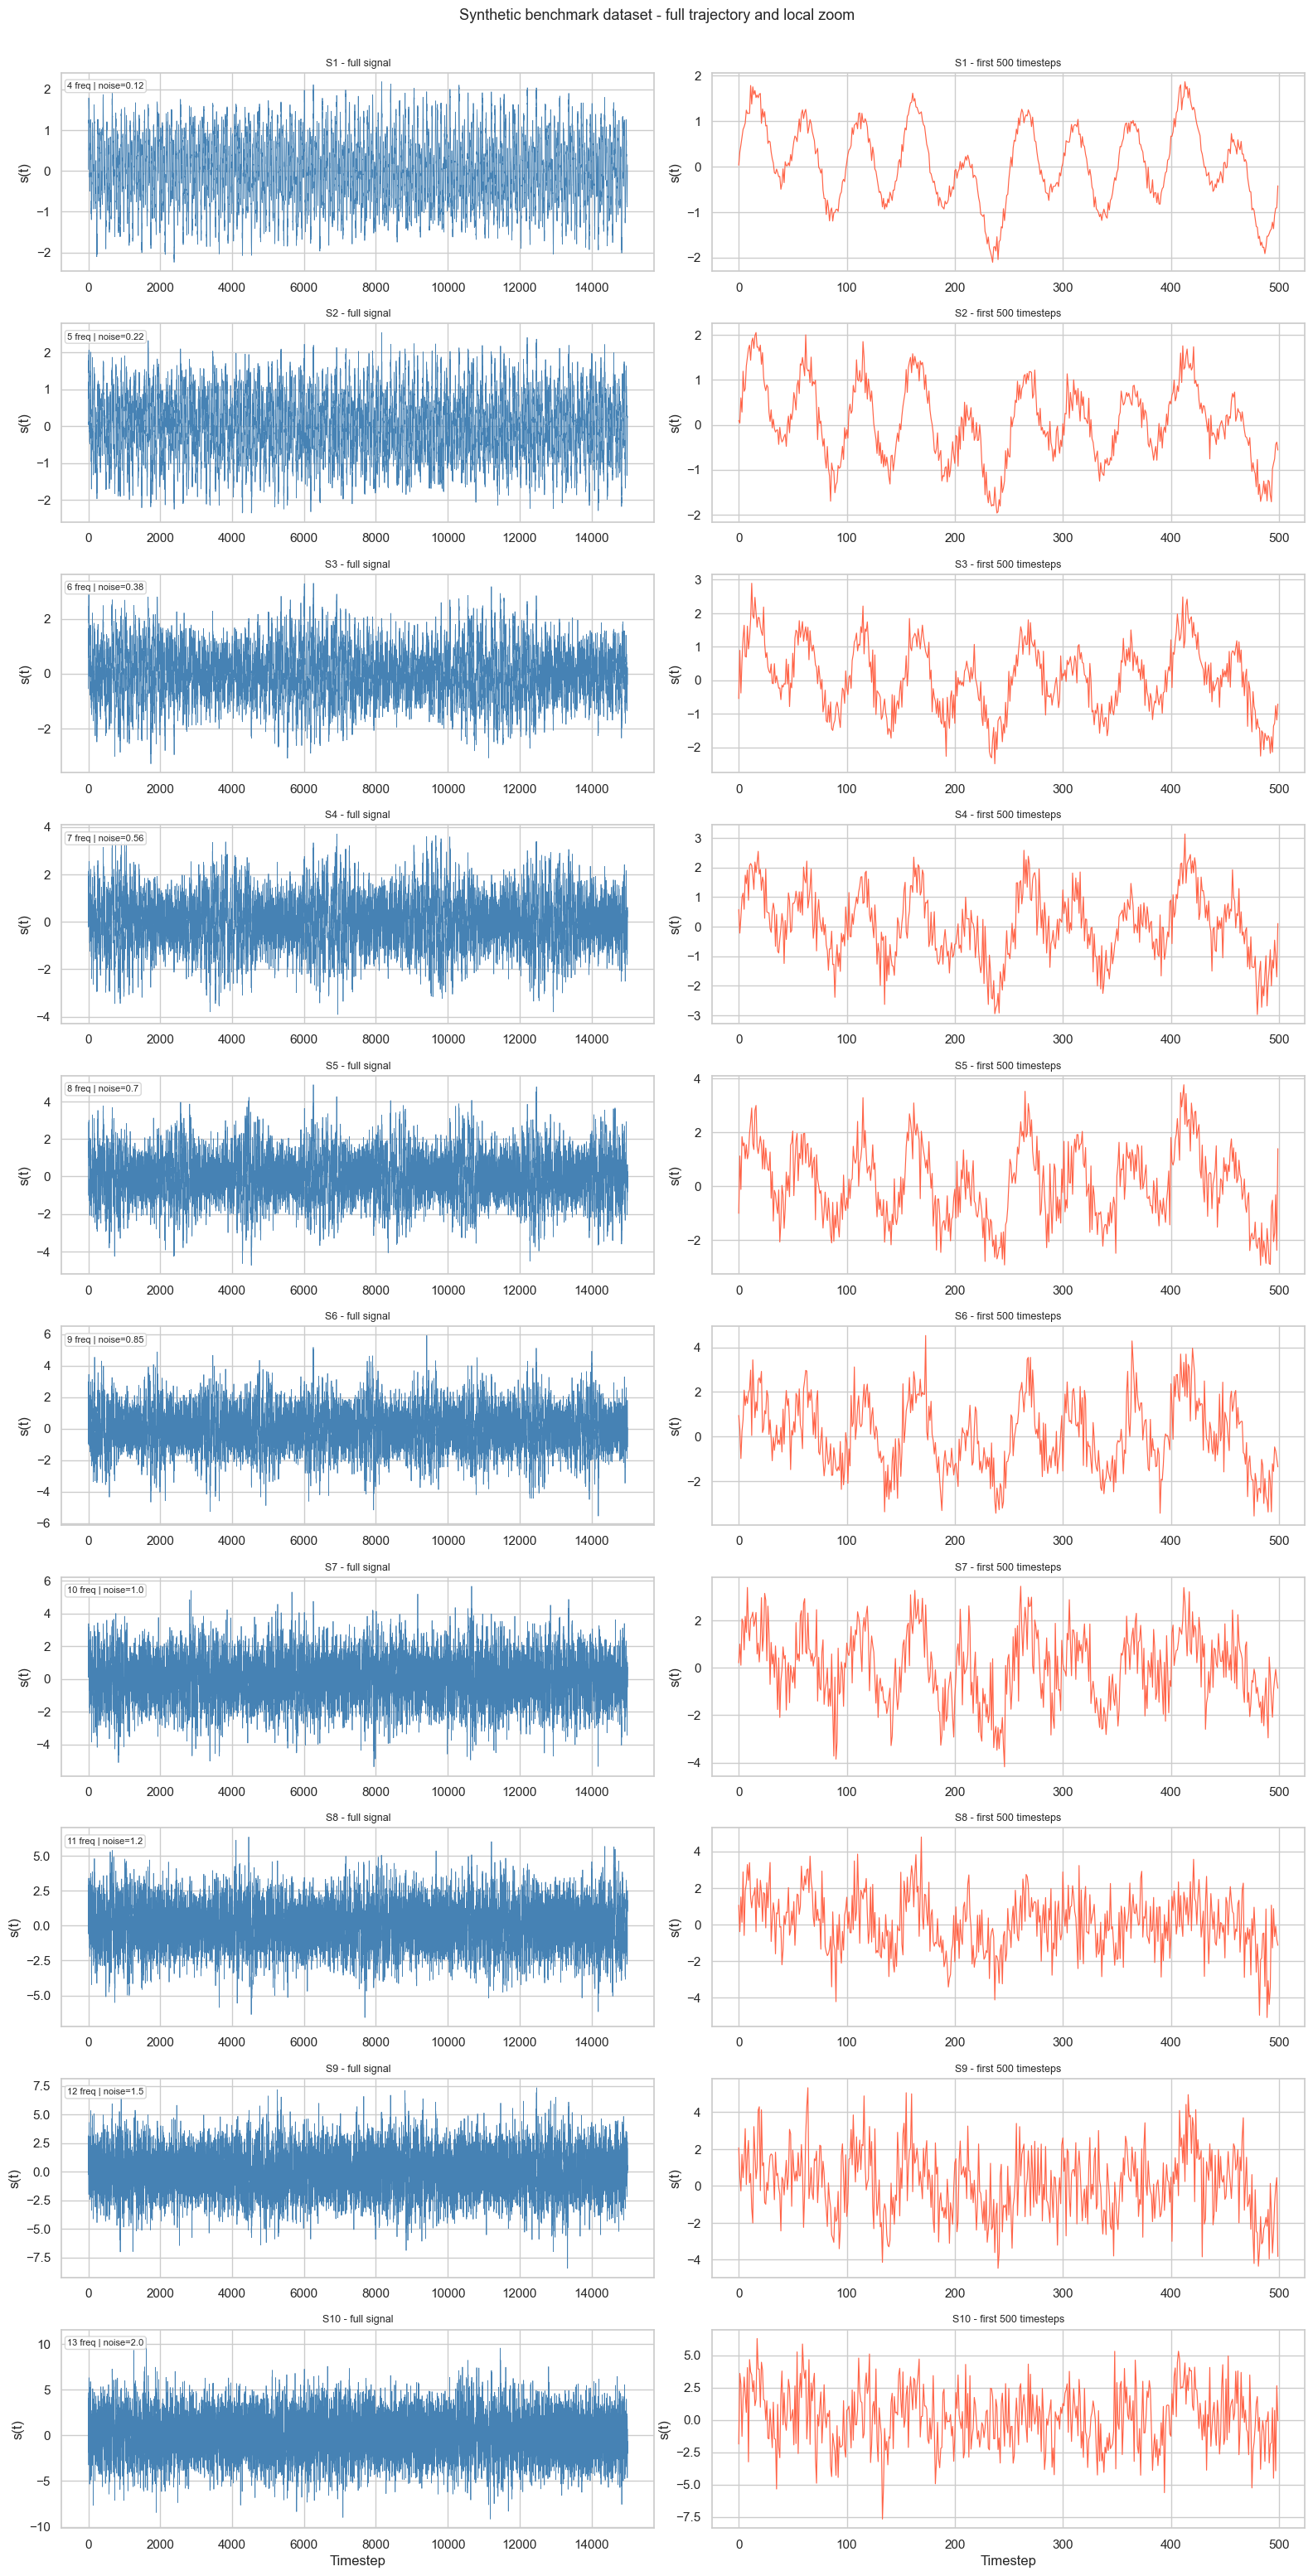

Figure saved → single_hp_outputs_4/benchmark_signals_overview.png


In [5]:
# ---------------------------------------------------------------------------
# Full benchmark signal overview: entire trajectory + local zoom
# ---------------------------------------------------------------------------
signal_order = list(SIGNALS.keys())
n_signals = len(signal_order)

fig, axes = plt.subplots(n_signals, 2, figsize=(16, 3.1 * n_signals), sharex=False)

for row, sig_name in enumerate(signal_order):
    sig_cfg = SIGNALS[sig_name]
    signal = sig_cfg["data"]

    ax = axes[row, 0]
    ax.plot(t_axis, signal, lw=0.55, color="steelblue")
    ax.set_title(f"{sig_name} - full signal", fontsize=9)
    ax.set_ylabel("s(t)")
    ax.text(
        0.01,
        0.92,
        f"{sig_cfg['n_components']} freq | noise={sig_cfg['noise_std']}",
        transform=ax.transAxes,
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="lightgray", alpha=0.9),
    )

    ax = axes[row, 1]
    ax.plot(t_axis[:500], signal[:500], lw=0.85, color="tomato")
    ax.set_title(f"{sig_name} - first 500 timesteps", fontsize=9)
    ax.set_ylabel("s(t)")

axes[-1, 0].set_xlabel("Timestep")
axes[-1, 1].set_xlabel("Timestep")
fig.suptitle("Synthetic benchmark dataset - full trajectory and local zoom", fontsize=13, y=1.002)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "benchmark_signals_overview.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Figure saved → {OUTPUT_DIR / 'benchmark_signals_overview.png'}")


This figure plays the same role as the full-series plot in Notebook 2, but for the entire
benchmark family:

- The **left column** shows the full trajectory of each synthetic signal.
- The **right column** isolates the first 500 timesteps so beat notes, local noise, and
  amplitude-modulation effects are visible.
- Reading **top to bottom** should reveal the deliberate difficulty escalation built into
  the benchmark.


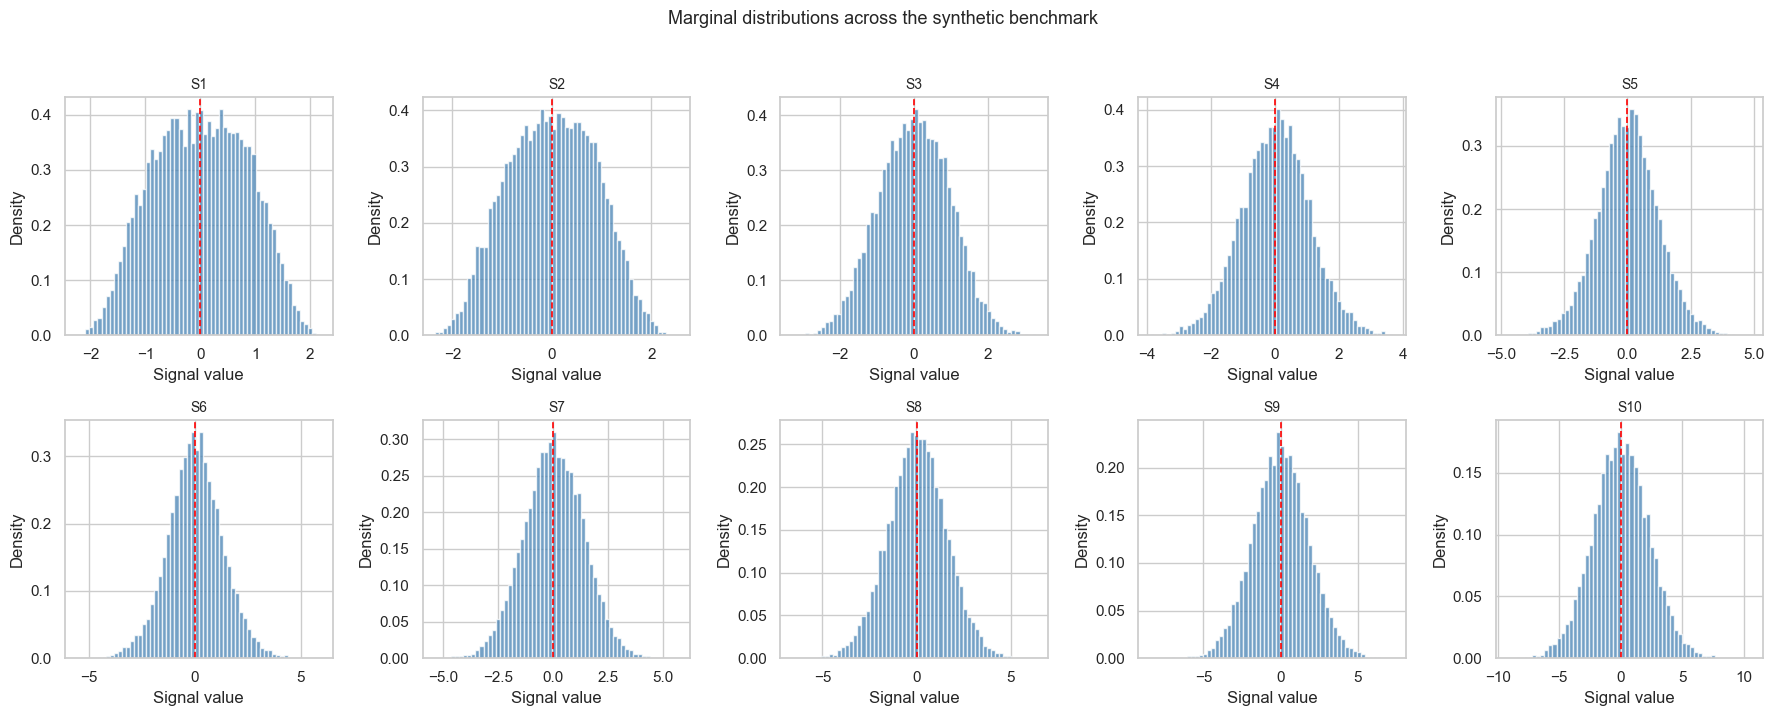

Figure saved → single_hp_outputs_4/benchmark_distributions.png

Distribution descriptors

signal   mean    std    skew  kurtosis     q05  median    q95
    S1 0.0025 0.8467 -0.0187   -0.7881 -1.3658  0.0063 1.3626
   S10 0.0012 2.2970  0.0147    0.1085 -3.7802 -0.0113 3.7866
    S2 0.0024 0.8783 -0.0212   -0.6844 -1.4397  0.0076 1.4184
    S3 0.0003 0.9602 -0.0067   -0.2274 -1.5768  0.0110 1.5532
    S4 0.0051 1.0673 -0.0220    0.1193 -1.7661  0.0213 1.7658
    S5 0.0003 1.2016 -0.0065    0.2780 -1.9828  0.0069 1.9884
    S6 0.0058 1.3069 -0.0072    0.3968 -2.1437 -0.0065 2.1561
    S7 0.0146 1.3627 -0.0413    0.1068 -2.2395  0.0178 2.2307
    S8 0.0168 1.5614 -0.0213    0.1729 -2.5441  0.0190 2.5787
    S9 0.0033 1.8293  0.0131    0.2271 -2.9999 -0.0042 3.0182


In [6]:
# ---------------------------------------------------------------------------
# Marginal distributions by signal
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=False)
axes = axes.ravel()

for ax, sig_name in zip(axes, signal_order):
    subset = benchmark_long_df.loc[benchmark_long_df["signal"] == sig_name, "value"].values
    ax.hist(subset, bins=60, density=True, alpha=0.75, color="steelblue", edgecolor="white")
    ax.axvline(subset.mean(), color="red", linestyle="--", linewidth=1.2)
    ax.set_title(sig_name, fontsize=10)
    ax.set_xlabel("Signal value")
    ax.set_ylabel("Density")

fig.suptitle("Marginal distributions across the synthetic benchmark", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "benchmark_distributions.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Figure saved → {OUTPUT_DIR / 'benchmark_distributions.png'}")

print("\nDistribution descriptors\n")
print(
    signal_stats[
        ["signal", "mean", "std", "skew", "kurtosis", "q05", "median", "q95"]
    ].to_string(index=False, float_format=lambda x: f"{x:.4f}")
)


This distribution view mirrors the histogram analysis in Notebook 2.

For the benchmark, it is especially useful for checking:
- whether stronger noise mostly widens the distribution or also distorts its symmetry,
- whether amplitude modulation creates heavier tails,
- and whether the benchmark difficulty increase is visible not only in time-domain plots
  but also in the marginal statistics.


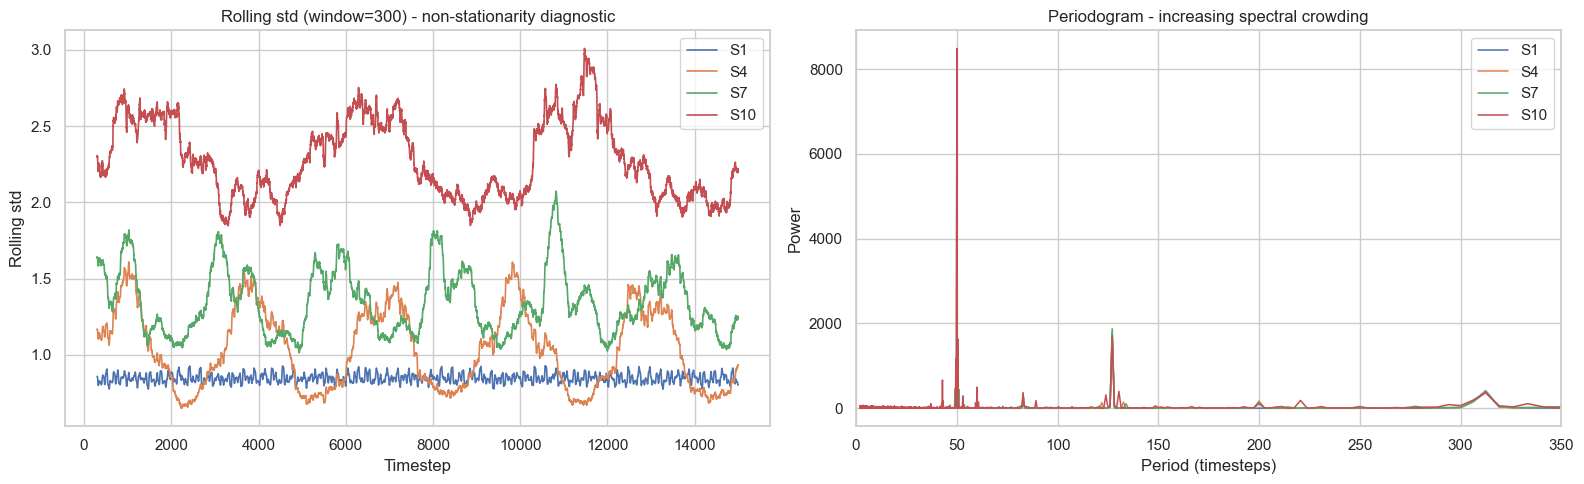

Figure saved → single_hp_outputs_4/benchmark_complexity_diagnostics.png

Top periodogram peaks for selected benchmark signals

signal  dominant_period    power
    S1           50.000 7509.602
    S1          127.119 1801.066
    S1          312.500  411.850
    S1           82.873  362.851
    S1          306.122  153.860
   S10           50.000 8486.434
   S10          127.119 1710.887
   S10           50.505 1629.511
   S10           49.505 1163.762
   S10           42.857  665.050
    S4           50.000 7562.925
    S4          127.119 1749.793
    S4           49.180  465.805
    S4           50.847  433.508
    S4          312.500  390.896
    S7           50.000 7405.654
    S7          127.119 1874.041
    S7           51.020  440.849
    S7           49.020  386.784
    S7          312.500  370.028


In [7]:
# ---------------------------------------------------------------------------
# Complexity diagnostics:
#   1. Rolling standard deviation (non-stationarity)
#   2. Periodogram peaks (spectral crowding)
# ---------------------------------------------------------------------------
selected_signals = ["S1", "S4", "S7", "S10"]
rolling_window = 300

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Rolling standard deviation
ax = axes[0]
for sig_name in selected_signals:
    s = pd.Series(SIGNALS[sig_name]["data"])
    roll_std = s.rolling(rolling_window).std()
    ax.plot(roll_std.index, roll_std.values, lw=1.2, label=sig_name)
ax.set_title(f"Rolling std (window={rolling_window}) - non-stationarity diagnostic")
ax.set_xlabel("Timestep")
ax.set_ylabel("Rolling std")
ax.legend()

# Periodograms
ax = axes[1]
dominant_rows = []
for sig_name in selected_signals:
    sig = SIGNALS[sig_name]["data"]
    freqs, power = periodogram(sig)
    valid = freqs > 0
    freqs = freqs[valid]
    power = power[valid]
    periods = 1 / freqs

    mask = periods <= 600
    ax.plot(periods[mask], power[mask], lw=1.1, label=sig_name)

    top_idx = np.argsort(power)[-5:][::-1]
    for idx in top_idx:
        dominant_rows.append(
            {
                "signal": sig_name,
                "dominant_period": periods[idx],
                "power": power[idx],
            }
        )

ax.set_title("Periodogram - increasing spectral crowding")
ax.set_xlabel("Period (timesteps)")
ax.set_ylabel("Power")
ax.set_xlim(0, 350)
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "benchmark_complexity_diagnostics.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Figure saved → {OUTPUT_DIR / 'benchmark_complexity_diagnostics.png'}")

dominant_periods_df = (
    pd.DataFrame(dominant_rows)
    .sort_values(["signal", "power"], ascending=[True, False])
    .groupby("signal")
    .head(5)
    .reset_index(drop=True)
)

print("\nTop periodogram peaks for selected benchmark signals\n")
print(dominant_periods_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


This benchmark-specific diagnostic replaces the seasonal cycle analysis from Notebook 2.

- The **rolling standard deviation** is the simplest way to reveal amplitude modulation and
  non-stationary envelope strength.
- The **periodogram** shows how the reservoir's memory problem becomes harder as frequency
  components become more crowded and beat structures accumulate.

Together, these two views explain *why* later signals should be harder for the ESN, before
any model is trained.


<br>

---

## 4. Echo State Network Methodology

### 4.1. Supervised Dataset Construction

Each benchmark signal is treated as a **1-D univariate forecasting task**. As in Notebook 2,
we construct a lagged input window of length `L = 10` and predict the next timestep.

For any signal \(s(t)\):

\[
\mathbf{x}_t = [s_{t-9}, s_{t-8}, \ldots, s_{t-1}, s_t] \in \mathbb{R}^{10}
\]

\[
y_t = s_{t+1}
\]

The benchmark-wide random search is run on the core subset `S1-S4`. After that first pass,
the notebook chooses an **anchor signal** for the detailed analysis:
- by default, the **hardest core signal** according to best achievable CV RMSE,
- or a user-defined signal if `FORCE_ANALYSIS_SIGNAL` is set above.


In [8]:
# ---------------------------------------------------------------------------
# Lagged supervised datasets for every benchmark signal
# ---------------------------------------------------------------------------
def build_dataset(signal, lag=LAG):
    signal = np.asarray(signal)
    t_len = len(signal)
    X = np.column_stack([signal[i : t_len - lag + i] for i in range(lag)])
    y = signal[lag:].reshape(-1, 1)
    return X, y


DATASETS = {}
dataset_rows = []
for sig_name, sig_cfg in SIGNALS.items():
    X_sig, y_sig = build_dataset(sig_cfg["data"], lag=LAG)
    DATASETS[sig_name] = {"X": X_sig, "y": y_sig}
    dataset_rows.append(
        {
            "signal": sig_name,
            "X_shape": X_sig.shape,
            "y_shape": y_sig.shape,
            "n_components": sig_cfg["n_components"],
            "noise_std": sig_cfg["noise_std"],
        }
    )

dataset_shapes_df = pd.DataFrame(dataset_rows)
print("Supervised dataset summary\n")
print(dataset_shapes_df.to_string(index=False))


Supervised dataset summary

signal     X_shape    y_shape  n_components  noise_std
    S1 (14990, 10) (14990, 1)             4       0.12
    S2 (14990, 10) (14990, 1)             5       0.22
    S3 (14990, 10) (14990, 1)             6       0.38
    S4 (14990, 10) (14990, 1)             7       0.56
    S5 (14990, 10) (14990, 1)             8       0.70
    S6 (14990, 10) (14990, 1)             9       0.85
    S7 (14990, 10) (14990, 1)            10       1.00
    S8 (14990, 10) (14990, 1)            11       1.20
    S9 (14990, 10) (14990, 1)            12       1.50
   S10 (14990, 10) (14990, 1)            13       2.00


### 4.2. Overview of Reservoir Computing

Echo State Networks transform each lag window into a high-dimensional recurrent state:

\[
\mathbf{h}_t = (1 - \alpha)\,\mathbf{h}_{t-1}
+ \alpha \tanh \left( W_{in}\mathbf{x}_t + W\mathbf{h}_{t-1} \right)
\]

where:
- \(N\) controls the size of the reservoir,
- \(\rho(W)\) controls the dynamical timescale and stability,
- \(\alpha\) controls how quickly the state reacts to new input,
- the readout is fitted with ridge regression.

The benchmark is especially useful because it stresses the ESN in a controlled way:
- **more frequencies** demand richer state separation,
- **stronger beating** demands longer fading memory,
- **amplitude modulation** demands adaptation to slowly changing envelope statistics.

As in Notebook 2, **temporal cross-validation** is mandatory. Standard shuffled k-fold CV
would leak future signal regimes into the training data and would invalidate the conclusions.


<br>

---

## 5. Phase A - Hyperparameter Study

We begin with a **random search** over the core benchmark subset `S1-S4`.

A full Cartesian grid across all signals would be prohibitively expensive. The strategy is:
1. sample a broad but computationally practical set of ESN configurations,
2. run strict temporal CV independently on `S1-S4`,
3. extract the best configuration for each core signal,
4. choose the anchor signal for the detailed Notebook-2-style OAT analysis.


In [9]:
# ---------------------------------------------------------------------------
# Phase A hyperparameter space
# ---------------------------------------------------------------------------
HP_GRID = {
    "N":       [20, 30, 50, 100, 200],
    "sr":      [0.5, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5],
    "lr":      [0.01, 0.05, 0.1, 0.2, 0.5, 1.0],
    "ridge":   [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    "washout": [5, 10, 20, 50],
}
N_HP_CONFIGS = 100

all_combos = list(ParameterGrid(HP_GRID))
sampled_configs = random.Random().sample(
    all_combos, min(N_HP_CONFIGS, len(all_combos))
)

total_evals = len(sampled_configs) * N_SPLITS * len(CORE_SIGNALS)
print(f"Full grid size        : {len(all_combos)}")
print(f"Random-search configs : {len(sampled_configs)}")
print(f"CV folds              : {N_SPLITS}")
print(f"Core signals          : {CORE_SIGNALS}")
print(f"Total model fits      : {total_evals}")


Full grid size        : 4200
Random-search configs : 100
CV folds              : 10
Core signals          : ['S1', 'S2', 'S3', 'S4']
Total model fits      : 4000


In [10]:
# ---------------------------------------------------------------------------
# Phase A helpers and random search on the core benchmark signals
# ---------------------------------------------------------------------------
def run_esn_cv_search(X, y, configs, signal_name, n_splits=N_SPLITS):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = []
    total = len(configs) * n_splits
    done = 0
    t0_all = time.time()

    for cfg_idx, cfg in enumerate(configs):
        for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X)):
            done += 1
            X_tr_f, y_tr_f = X[train_idx], y[train_idx]
            X_te_f, y_te_f = X[test_idx], y[test_idx]

            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr_f)
            X_te = scaler.transform(X_te_f)

            try:
                t0 = time.time()
                reservoir = Reservoir(
                    units=int(cfg["N"]),
                    sr=cfg["sr"],
                    lr=cfg["lr"],
                )
                model = reservoir >> Ridge(ridge=cfg["ridge"])
                model.fit(X_tr, y_tr_f, warmup=int(cfg["washout"]))
                y_pred = np.asarray(model.run(X_te)).reshape(-1)
                y_true = y_te_f.ravel()

                results.append(
                    {
                        "signal": signal_name,
                        "config_idx": cfg_idx,
                        "fold": fold_idx,
                        "N": int(cfg["N"]),
                        "sr": float(cfg["sr"]),
                        "lr": float(cfg["lr"]),
                        "ridge": float(cfg["ridge"]),
                        "washout": int(cfg["washout"]),
                        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
                        "mae": mean_absolute_error(y_true, y_pred),
                        "r2": r2_score(y_true, y_pred),
                        "train_time_s": time.time() - t0,
                        "n_train": len(train_idx),
                        "n_test": len(test_idx),
                    }
                )
            except Exception as exc:
                results.append(
                    {
                        "signal": signal_name,
                        "config_idx": cfg_idx,
                        "fold": fold_idx,
                        "N": int(cfg["N"]),
                        "sr": float(cfg["sr"]),
                        "lr": float(cfg["lr"]),
                        "ridge": float(cfg["ridge"]),
                        "washout": int(cfg["washout"]),
                        "rmse": np.nan,
                        "mae": np.nan,
                        "r2": np.nan,
                        "train_time_s": np.nan,
                        "n_train": len(train_idx),
                        "n_test": len(test_idx),
                        "error": str(exc),
                    }
                )

        if (cfg_idx + 1) % 20 == 0 or cfg_idx == 0:
            elapsed = time.time() - t0_all
            rate = done / elapsed if elapsed > 0 else np.nan
            print(
                f"    [{signal_name}] {cfg_idx + 1:3d}/{len(configs)} configs"
                f" | elapsed={elapsed/60:.1f} min | rate={rate:.2f} eval/s"
            )

    return pd.DataFrame(results)


def aggregate_phase_a(df):
    group_cols = ["signal", "config_idx", "N", "sr", "lr", "ridge", "washout"]
    return (
        df.dropna(subset=["rmse"])
        .groupby(group_cols)
        .agg(
            rmse_mean=("rmse", "mean"),
            rmse_std=("rmse", "std"),
            mae_mean=("mae", "mean"),
            mae_std=("mae", "std"),
            r2_mean=("r2", "mean"),
            r2_std=("r2", "std"),
            train_time_mean=("train_time_s", "mean"),
            n_folds=("fold", "count"),
        )
        .reset_index()
        .sort_values(["signal", "rmse_mean"])
    )


def params_from_row(row):
    return {
        "N": int(row["N"]),
        "sr": float(row["sr"]),
        "lr": float(row["lr"]),
        "ridge": float(row["ridge"]),
        "washout": int(row["washout"]),
    }


phase_a_frames = []
for sig_name in CORE_SIGNALS:
    print(f"\n{'=' * 68}")
    print(f"Phase A random search - {sig_name}: {SIGNALS[sig_name]['label']}")
    print(f"{'=' * 68}")
    X_sig = DATASETS[sig_name]["X"]
    y_sig = DATASETS[sig_name]["y"]
    df_sig = run_esn_cv_search(X_sig, y_sig, sampled_configs, signal_name=sig_name)
    phase_a_frames.append(df_sig)

df_phase_a = pd.concat(phase_a_frames, ignore_index=True)
agg_phase_a = aggregate_phase_a(df_phase_a)

df_phase_a.to_csv(OUTPUT_DIR / "phase_a_random_search_fold_results.csv", index=False)
agg_phase_a.to_csv(OUTPUT_DIR / "phase_a_random_search_summary.csv", index=False)

print(f"\nFold-level Phase A results saved → {OUTPUT_DIR / 'phase_a_random_search_fold_results.csv'}")
print(f"Aggregate Phase A summary saved → {OUTPUT_DIR / 'phase_a_random_search_summary.csv'}")



Phase A random search - S1: S1 - 4 freq, sr=0.12
    [S1]   1/100 configs | elapsed=0.0 min | rate=4.43 eval/s
    [S1]  20/100 configs | elapsed=0.6 min | rate=5.65 eval/s
    [S1]  40/100 configs | elapsed=1.1 min | rate=5.91 eval/s
    [S1]  60/100 configs | elapsed=1.7 min | rate=5.96 eval/s
    [S1]  80/100 configs | elapsed=4.5 min | rate=2.99 eval/s
    [S1] 100/100 configs | elapsed=5.0 min | rate=3.31 eval/s

Phase A random search - S2: S2 - 5 freq + beating, sr=0.22
    [S2]   1/100 configs | elapsed=0.0 min | rate=9.16 eval/s
    [S2]  20/100 configs | elapsed=0.5 min | rate=7.18 eval/s
    [S2]  40/100 configs | elapsed=1.0 min | rate=6.86 eval/s
    [S2]  60/100 configs | elapsed=1.5 min | rate=6.79 eval/s
    [S2]  80/100 configs | elapsed=2.1 min | rate=6.49 eval/s
    [S2] 100/100 configs | elapsed=2.6 min | rate=6.43 eval/s

Phase A random search - S3: S3 - 6 freq + AM, sr=0.38
    [S3]   1/100 configs | elapsed=0.0 min | rate=7.73 eval/s
    [S3]  20/100 configs | el

<br>

<br>

### 5.1. Phase A - Results Summary


In [11]:
# ---------------------------------------------------------------------------
# Best configuration per core signal and anchor-signal selection
# ---------------------------------------------------------------------------
best_phase_a_per_signal = (
    agg_phase_a.sort_values(["signal", "rmse_mean"])
    .groupby("signal", as_index=False)
    .first()
    .sort_values("rmse_mean")
    .reset_index(drop=True)
)

BEST_PARAMS_PER_SIGNAL = {
    row["signal"]: params_from_row(row) for _, row in best_phase_a_per_signal.iterrows()
}

if FORCE_ANALYSIS_SIGNAL is not None:
    ANALYSIS_SIGNAL = FORCE_ANALYSIS_SIGNAL
else:
    ANALYSIS_SIGNAL = (
        best_phase_a_per_signal.sort_values("rmse_mean", ascending=False)
        .iloc[0]["signal"]
    )

best_params = BEST_PARAMS_PER_SIGNAL[ANALYSIS_SIGNAL]
X_anchor = DATASETS[ANALYSIS_SIGNAL]["X"]
y_anchor = DATASETS[ANALYSIS_SIGNAL]["y"]
anchor_cfg = SIGNALS[ANALYSIS_SIGNAL]

best_phase_a_per_signal.to_csv(OUTPUT_DIR / "phase_a_best_per_signal.csv", index=False)

print("Best random-search configuration per core signal\n")
display_cols = ["signal", "N", "sr", "lr", "ridge", "washout", "rmse_mean", "rmse_std", "r2_mean", "r2_std"]
print(best_phase_a_per_signal[display_cols].to_string(index=False, float_format=lambda x: f"{x:.5f}"))

print(f"\nAnchor signal selected for detailed Notebook-2-style analysis: {ANALYSIS_SIGNAL}")
print(f"  Label : {anchor_cfg['label']}")
print(f"  Desc  : {anchor_cfg['desc']}")
print(f"  Best params from random search: {best_params}")


Best random-search configuration per core signal

signal   N      sr      lr   ridge  washout  rmse_mean  rmse_std  r2_mean  r2_std
    S1 200 1.10000 0.10000 0.10000       20    0.13751   0.00556  0.97362 0.00205
    S2 200 1.10000 0.05000 0.10000       50    0.24720   0.00616  0.92095 0.00355
    S3 200 1.10000 0.10000 0.10000       20    0.42707   0.01318  0.76750 0.08944
    S4 200 1.10000 0.10000 0.10000       20    0.61647   0.02055  0.61031 0.13316

Anchor signal selected for detailed Notebook-2-style analysis: S4
  Label : S4 - 7 freq + strong AM, sr=0.56
  Desc  : Strong AM (T_AM=3 000) + dense multi-scale beating
  Best params from random search: {'N': 200, 'sr': 1.1, 'lr': 0.1, 'ridge': 0.1, 'washout': 20}


The table above serves two purposes:

1. It gives the **best achievable baseline** for each of the core benchmark signals.
2. It determines the **anchor signal** for the detailed ablation study.

By default, the anchor is the core signal with the **highest best RMSE**, i.e. the
hardest signal that still belongs to the detailed benchmark subset `S1-S4`.
This preserves Notebook 2's depth while grounding the analysis in the benchmark-wide
difficulty hierarchy.


In [12]:
import os as _os

_os.makedirs(OUTPUT_DIR, exist_ok=True)

def run_single_hp_study(X, y, hp_name, hp_values, base_params, n_splits=N_SPLITS, save_csv=None):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    records = []
    total = len(hp_values) * n_splits
    print(
        f"Single Hyperparameter Study '{hp_name}': {len(hp_values)} values x {n_splits} folds = {total} evaluations"
    )

    for val in hp_values:
        cfg = {**base_params, hp_name: val}
        for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X)):
            X_tr_f, y_tr_f = X[train_idx], y[train_idx]
            X_te_f, y_te_f = X[test_idx], y[test_idx]

            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr_f)
            X_te = scaler.transform(X_te_f)

            try:
                t0 = time.time()
                reservoir = Reservoir(
                    units=int(cfg["N"]),
                    sr=cfg["sr"],
                    lr=cfg["lr"],
                )
                model = reservoir >> Ridge(ridge=cfg["ridge"])
                model.fit(X_tr, y_tr_f, warmup=int(cfg["washout"]))
                y_pred = np.asarray(model.run(X_te)).reshape(-1)
                y_true = y_te_f.ravel()

                records.append(
                    {
                        hp_name: val,
                        "fold": fold_idx,
                        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
                        "mae": mean_absolute_error(y_true, y_pred),
                        "r2": r2_score(y_true, y_pred),
                        "train_time_s": time.time() - t0,
                    }
                )
            except Exception as exc:
                print(f"  [ERROR] {hp_name}={val}, fold {fold_idx}: {exc}")
                records.append(
                    {
                        hp_name: val,
                        "fold": fold_idx,
                        "rmse": np.nan,
                        "mae": np.nan,
                        "r2": np.nan,
                        "train_time_s": np.nan,
                    }
                )

    df_out = pd.DataFrame(records)
    if save_csv is not None:
        df_out.to_csv(save_csv, index=False)
        print(f"  CSV saved → {save_csv}")
    return df_out


def plot_single_hp(df, hp_name, hp_values, label_map=None, title=None, palette="colorblind", save_path=None):
    labels = [label_map[v] if label_map else str(v) for v in hp_values]
    df_plot = df.dropna(subset=["rmse"]).copy()
    df_plot["_lbl"] = df_plot[hp_name].map(dict(zip(hp_values, labels)))

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    if title:
        fig.suptitle(title, fontsize=11, fontweight="bold", y=1.01)

    ax = axes[0]
    sns.boxplot(data=df_plot, x="_lbl", y="rmse", order=labels, palette=palette, width=0.5, fliersize=0, ax=ax)
    sns.stripplot(data=df_plot, x="_lbl", y="rmse", order=labels, color="black", size=4, alpha=0.6, jitter=True, ax=ax)
    ax.set_xlabel(hp_name)
    ax.set_ylabel("RMSE")
    ax.set_title("RMSE - fold distribution")
    ax.tick_params(axis="x", rotation=45)

    ax = axes[1]
    summary = (
        df_plot.groupby("_lbl")["rmse"]
        .agg(["mean", "std"])
        .reindex(labels)
        .reset_index()
    )
    ax.errorbar(
        summary["_lbl"],
        summary["mean"],
        yerr=summary["std"],
        marker="o",
        capsize=6,
        linewidth=2,
        markersize=8,
        color="steelblue",
        elinewidth=1.5,
    )
    ax.set_xlabel(hp_name)
    ax.set_ylabel("Mean RMSE ± std")
    ax.set_title("Mean RMSE ± std across folds")
    ax.tick_params(axis="x", rotation=45)

    ax = axes[2]
    sns.boxplot(data=df_plot, x="_lbl", y="r2", order=labels, palette=palette, width=0.5, fliersize=0, ax=ax)
    sns.stripplot(data=df_plot, x="_lbl", y="r2", order=labels, color="black", size=4, alpha=0.6, jitter=True, ax=ax)
    ax.set_xlabel(hp_name)
    ax.set_ylabel("R²")
    ax.set_title("R² - fold distribution")
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=130, bbox_inches="tight")
        print(f"  Figure saved → {save_path}")
    plt.show()


def best_setting(df, param_name):
    agg = df.dropna(subset=["rmse"]).groupby(param_name)["rmse"].mean()
    return agg.idxmin()


def evaluate_holdout_prediction(signal, model_cfg, test_frac=0.25, W_custom=None):
    X_all, y_all = build_dataset(signal, lag=LAG)
    n = len(X_all)
    n_train = int(n * (1 - test_frac))

    X_train, y_train = X_all[:n_train], y_all[:n_train]
    X_test, y_test = X_all[n_train:], y_all[n_train:]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train)
    X_te = scaler.transform(X_test)

    if W_custom is None:
        reservoir = Reservoir(units=model_cfg["N"], sr=model_cfg["sr"], lr=model_cfg["lr"])
    else:
        reservoir = Reservoir(units=model_cfg["N"], W=W_custom, lr=model_cfg["lr"])

    model = reservoir >> Ridge(ridge=model_cfg["ridge"])
    model.fit(X_tr, y_train, warmup=int(model_cfg["washout"]))
    y_pred = np.asarray(model.run(X_te)).reshape(-1)
    y_true = y_test.ravel()

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
        "n_train": n_train,
    }


def plot_signal_prediction(
    sig_name,
    sig_cfg,
    model_cfg,
    title,
    test_frac=0.25,
    zoom=400,
    W_custom=None,
    ax_row=None,
    save_path=None,
):
    metrics = evaluate_holdout_prediction(sig_cfg["data"], model_cfg, test_frac=test_frac, W_custom=W_custom)
    y_true = metrics["y_true"]
    y_pred = metrics["y_pred"]
    n_train = metrics["n_train"]

    t_full = np.arange(len(sig_cfg["data"]))
    t_test = t_full[LAG + n_train :]

    own_fig = ax_row is None
    if own_fig:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    else:
        axes = ax_row

    ax = axes[0]
    ax.plot(t_full[: LAG + n_train], sig_cfg["data"][: LAG + n_train], lw=0.3, color="lightgray", label="Training signal")
    ax.plot(t_test, y_true, lw=0.8, color="steelblue", label="Real (test)")
    ax.plot(t_test, y_pred, lw=0.8, color="tomato", alpha=0.85, label="Predicted")
    ax.axvline(LAG + n_train, color="black", ls="--", lw=0.8)
    ax.set_title(f"{title}\nRMSE={metrics['rmse']:.4f} | MAE={metrics['mae']:.4f} | R²={metrics['r2']:.4f}", fontsize=9)
    ax.set_xlabel("Timestep")
    ax.set_ylabel("s(t)")
    ax.legend(fontsize=7, loc="upper left")

    ax = axes[1]
    ax.plot(t_test[:zoom], y_true[:zoom], lw=1.1, color="steelblue", label="Real")
    ax.plot(t_test[:zoom], y_pred[:zoom], lw=1.1, color="tomato", ls="--", label="Predicted")
    ax.set_title(f"Zoom - first {zoom} test timesteps", fontsize=9)
    ax.set_xlabel("Timestep")
    ax.set_ylabel("s(t)")
    ax.legend(fontsize=7)

    if own_fig:
        plt.tight_layout()
        if save_path is not None:
            plt.savefig(save_path, dpi=130, bbox_inches="tight")
            print(f"Figure saved → {save_path}")
        plt.show()

    return metrics


print(f"Anchor signal for detailed study: {ANALYSIS_SIGNAL}")
print(f"Anchor params from random search: {best_params}")


Anchor signal for detailed study: S4
Anchor params from random search: {'N': 200, 'sr': 1.1, 'lr': 0.1, 'ridge': 0.1, 'washout': 20}


### 5.2. Phase A - Hyperparameter Sensitivity Analysis

With the anchor signal fixed, we now reproduce Notebook 2's **one-at-a-time (OAT)**
sensitivity workflow. Each hyperparameter is swept across a broad range while the other four
remain fixed at the anchor signal's best random-search values.

This isolates the marginal effect of each hyperparameter on the benchmark signal that proved
hardest within the core subset.


Single Hyperparameter Study 'N': 10 values x 10 folds = 100 evaluations
  CSV saved → single_hp_outputs_4/shs_N.csv
  Figure saved → single_hp_outputs_4/shs_N.png


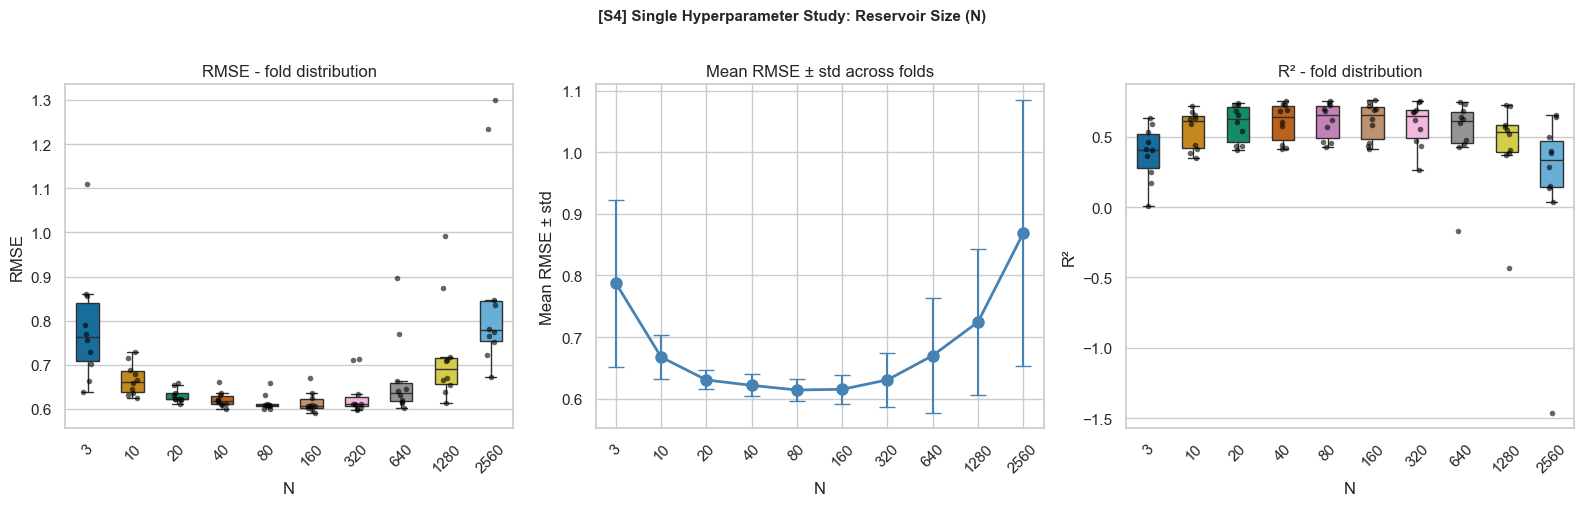

In [13]:
# Single Hyperparameter Study: Reservoir Size (N)
N_values = [3, 10, 20, 40, 80, 160, 320, 640, 1280, 2560]
df_shs_N = run_single_hp_study(
    X_anchor, y_anchor, "N", N_values, best_params,
    save_csv=OUTPUT_DIR / "shs_N.csv",
)
plot_single_hp(
    df_shs_N,
    "N",
    N_values,
    title=f"[{ANALYSIS_SIGNAL}] Single Hyperparameter Study: Reservoir Size (N)",
    save_path=OUTPUT_DIR / "shs_N.png",
)


#### 5.2.1. Sensitivity to Reservoir Size (N)

Tested values: `[3, 10, 20, 30, 50, 100, 200, 500, 1000]`

Read this sweep in three regimes:
- **under-capacity**: very small reservoirs cannot separate the competing oscillatory modes,
- **useful growth / elbow**: increasing `N` still improves representation quality,
- **variance-dominated regime**: larger `N` stops helping and may overparameterise the readout.

On the benchmark, `N` is expected to trade off **spectral richness** against **fold-level
variance**, especially on the earliest temporal splits where the training set is smallest.


Single Hyperparameter Study 'sr': 11 values x 10 folds = 110 evaluations
  CSV saved → single_hp_outputs_4/shs_sr.csv
  Figure saved → single_hp_outputs_4/shs_sr.png


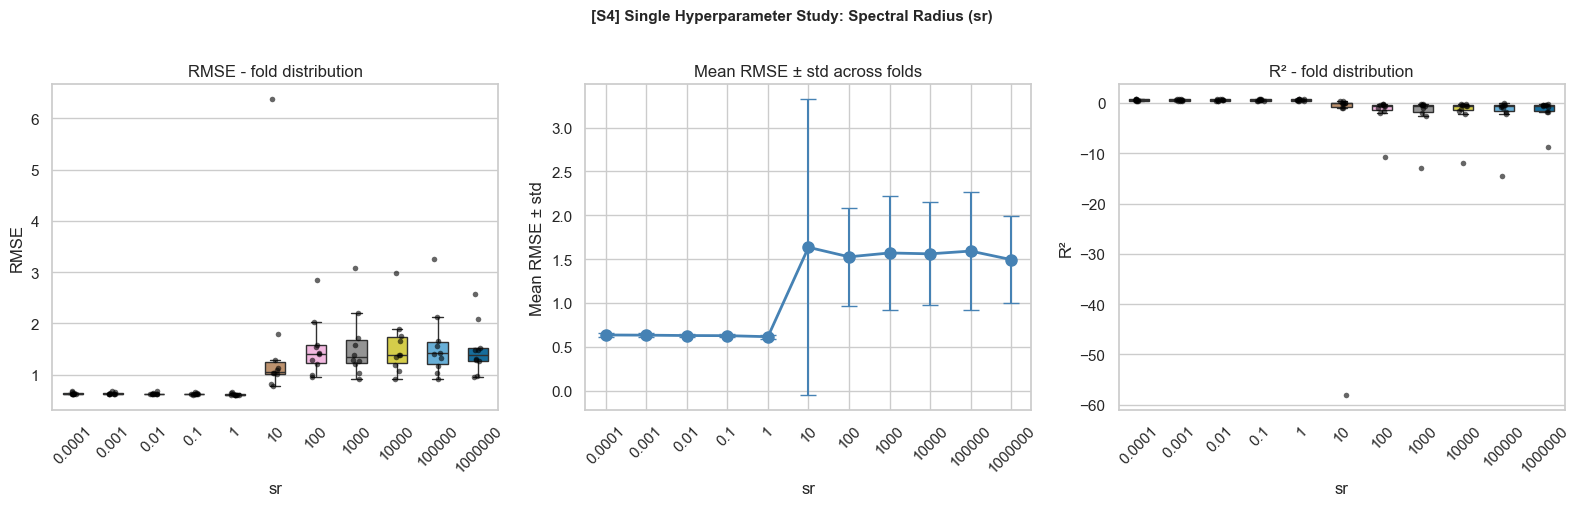

In [14]:
# Single Hyperparameter Study: Spectral Radius (sr)
sr_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]
df_shs_sr = run_single_hp_study(
    X_anchor, y_anchor, "sr", sr_values, best_params,
    save_csv=OUTPUT_DIR / "shs_sr.csv",
)
plot_single_hp(
    df_shs_sr,
    "sr",
    sr_values,
    title=f"[{ANALYSIS_SIGNAL}] Single Hyperparameter Study: Spectral Radius (sr)",
    save_path=OUTPUT_DIR / "shs_sr.png",
)


Single Hyperparameter Study 'sr': 9 values x 10 folds = 90 evaluations
  CSV saved → single_hp_outputs_4/shs_sr.csv
  Figure saved → single_hp_outputs_4/shs_sr.png


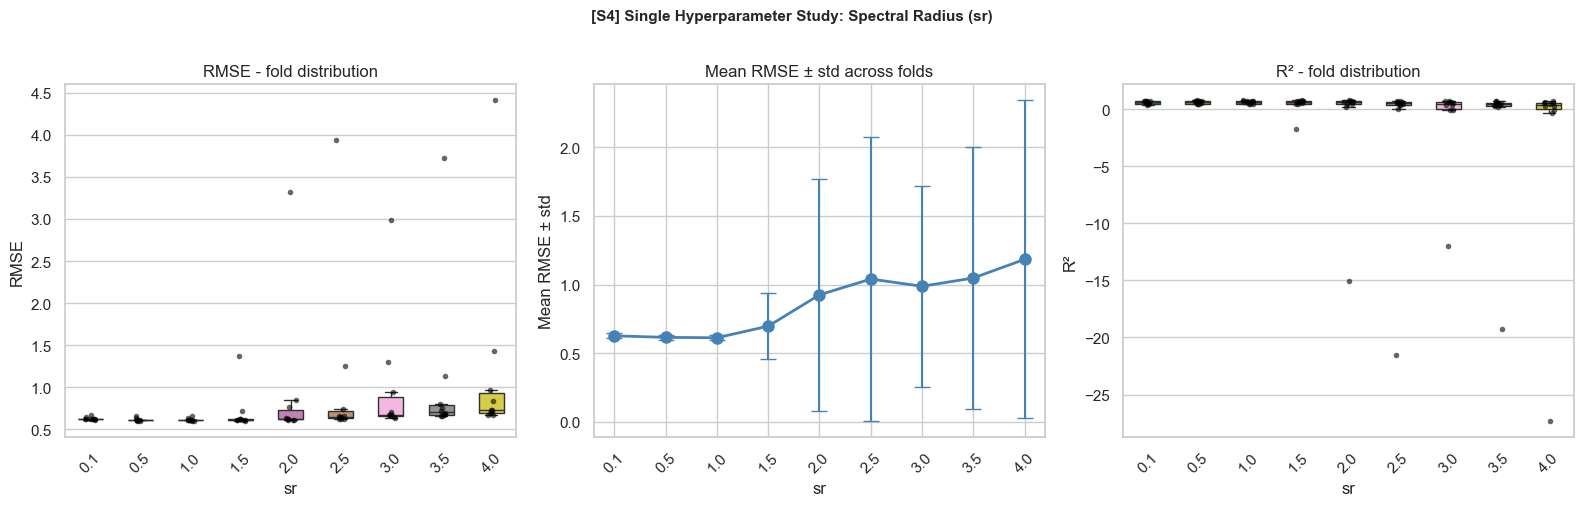

In [15]:
# Single Hyperparameter Study: Spectral Radius (sr)
sr_values = [0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
df_shs_sr = run_single_hp_study(
    X_anchor, y_anchor, "sr", sr_values, best_params,
    save_csv=OUTPUT_DIR / "shs_sr.csv",
)
plot_single_hp(
    df_shs_sr,
    "sr",
    sr_values,
    title=f"[{ANALYSIS_SIGNAL}] Single Hyperparameter Study: Spectral Radius (sr)",
    save_path=OUTPUT_DIR / "shs_sr.png",
)


#### 5.2.2. Sensitivity to Spectral Radius (sr)

Tested values: `[0.001, 0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.5, 2.1]`

This sweep should be interpreted as a **memory-vs-stability** analysis:
- very small `sr` suppresses the recurrent dynamics,
- intermediate `sr` values typically provide the useful fading-memory regime,
- large `sr` values push the reservoir toward unstable or chaotic dynamics.

The benchmark is a good stress test because beat structures and amplitude modulation create
a real need for memory, but excessive memory is no longer beneficial once the state becomes noisy.


Single Hyperparameter Study 'lr': 12 values x 10 folds = 120 evaluations
  [ERROR] lr=100.0, fold 0: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 1: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 2: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 3: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 4: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 5: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 6: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 7: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 8: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 9: array must not contain infs or NaNs
  CSV saved → single_hp_outputs_4/shs_lr.csv
  Figure saved → single_hp_outputs_4/shs_lr.png


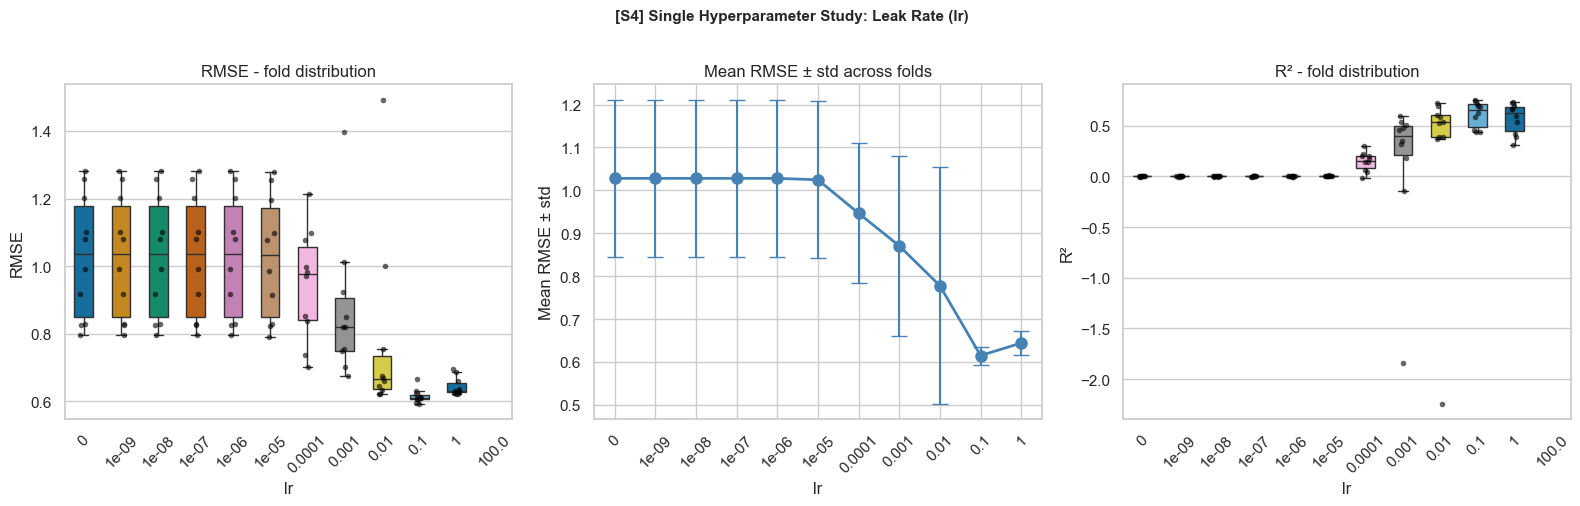

In [16]:
# Single Hyperparameter Study: Leak Rate (lr)
lr_values = [0, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 1e2]
df_shs_lr = run_single_hp_study(
    X_anchor, y_anchor, "lr", lr_values, best_params,
    save_csv=OUTPUT_DIR / "shs_lr.csv",
)
plot_single_hp(
    df_shs_lr,
    "lr",
    lr_values,
    title=f"[{ANALYSIS_SIGNAL}] Single Hyperparameter Study: Leak Rate (lr)",
    save_path=OUTPUT_DIR / "shs_lr.png",
)


Single Hyperparameter Study 'lr': 15 values x 10 folds = 150 evaluations
  [ERROR] lr=2.1, fold 2: array must not contain infs or NaNs
  [ERROR] lr=2.1, fold 3: array must not contain infs or NaNs
  [ERROR] lr=2.1, fold 4: array must not contain infs or NaNs
  [ERROR] lr=2.1, fold 5: array must not contain infs or NaNs
  [ERROR] lr=2.1, fold 6: array must not contain infs or NaNs
  [ERROR] lr=2.1, fold 7: array must not contain infs or NaNs
  [ERROR] lr=2.1, fold 8: array must not contain infs or NaNs
  [ERROR] lr=2.1, fold 9: array must not contain infs or NaNs
  [ERROR] lr=2.2, fold 1: array must not contain infs or NaNs
  [ERROR] lr=2.2, fold 2: array must not contain infs or NaNs
  [ERROR] lr=2.2, fold 3: array must not contain infs or NaNs
  [ERROR] lr=2.2, fold 4: array must not contain infs or NaNs
  [ERROR] lr=2.2, fold 5: array must not contain infs or NaNs
  [ERROR] lr=2.2, fold 6: array must not contain infs or NaNs
  [ERROR] lr=2.2, fold 7: array must not contain infs or Na

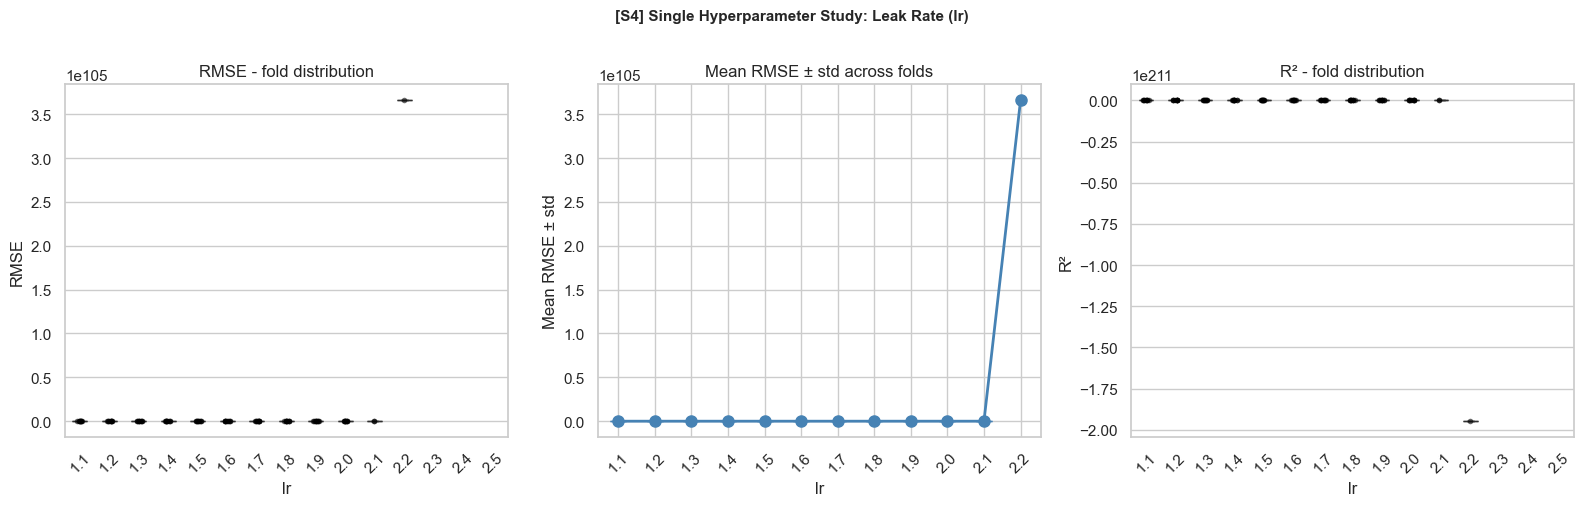

In [17]:
# Single Hyperparameter Study: Leak Rate (lr)
lr_values = [1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5]
df_shs_lr = run_single_hp_study(
    X_anchor, y_anchor, "lr", lr_values, best_params,
    save_csv=OUTPUT_DIR / "shs_lr.csv",
)
plot_single_hp(
    df_shs_lr,
    "lr",
    lr_values,
    title=f"[{ANALYSIS_SIGNAL}] Single Hyperparameter Study: Leak Rate (lr)",
    save_path=OUTPUT_DIR / "shs_lr.png",
)


#### 5.2.3. Sensitivity to Leak Rate (lr)

Tested values: `[1e-5, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 1.3]`

The leak rate controls how aggressively the reservoir reacts to new input:
- **too small**: the state changes too slowly and the reservoir becomes inertial,
- **intermediate**: useful fading memory without frozen dynamics,
- **too large**: potential overshoot or excessive reactivity.

For the synthetic benchmark, this parameter is especially important because the model must
balance **fast oscillations** against **slow envelopes** within the same recurrent state.


Single Hyperparameter Study 'ridge': 13 values x 10 folds = 130 evaluations
  CSV saved → single_hp_outputs_4/shs_ridge.csv
  Figure saved → single_hp_outputs_4/shs_ridge.png


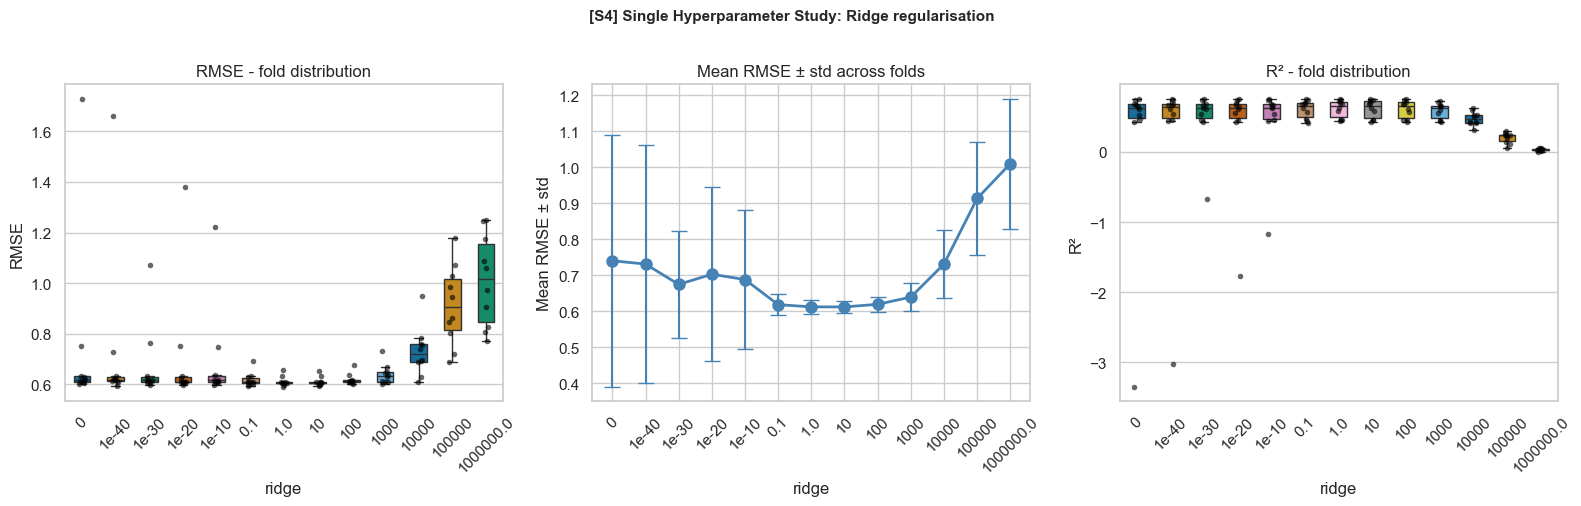

In [18]:
# Single Hyperparameter Study: Ridge
ridge_values = [0, 1e-40, 1e-30, 1e-20, 1e-10, 1e-1, 1.0, 10, 100, 1000, 10000, 100000, 1e6]
df_shs_ridge = run_single_hp_study(
    X_anchor, y_anchor, "ridge", ridge_values, best_params,
    save_csv=OUTPUT_DIR / "shs_ridge.csv",
)
plot_single_hp(
    df_shs_ridge,
    "ridge",
    ridge_values,
    title=f"[{ANALYSIS_SIGNAL}] Single Hyperparameter Study: Ridge regularisation",
    save_path=OUTPUT_DIR / "shs_ridge.png",
)


#### 5.2.4. Sensitivity to Ridge Regularisation

Tested values: `[1e-8, 1e-6, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10, 100]`

This sweep isolates how much readout regularisation is needed once the reservoir state has
already been fixed by `N`, `sr`, and `lr`.

In practice, ridge usually reveals three zones:
- **too small**: numerically fragile or overfit readout,
- **safe plateau**: broad range of nearly equivalent performance,
- **too large**: underfit readout that collapses toward the mean.


Single Hyperparameter Study 'washout': 7 values x 10 folds = 70 evaluations
  [ERROR] washout=10000, fold 0: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 1: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 2: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 3: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 4: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 5: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 6: array must not contain infs or NaNs
  [ERROR] washout=100000, fold 0: array must not contain infs or NaNs
  [ERROR] washout=100000, fold 1: array must not contain infs or NaNs
  [ERROR] washout=100000, fold 2: array must not contain infs or NaNs
  [ERROR] washout=100000, fold 3: array must not contain infs or NaNs
  [ERROR] washout=100000, fold 4: array must not contain infs or NaNs
  [ERROR] washout=100000, fold 5: array must not contain infs or NaNs
  [ERROR] washout=100

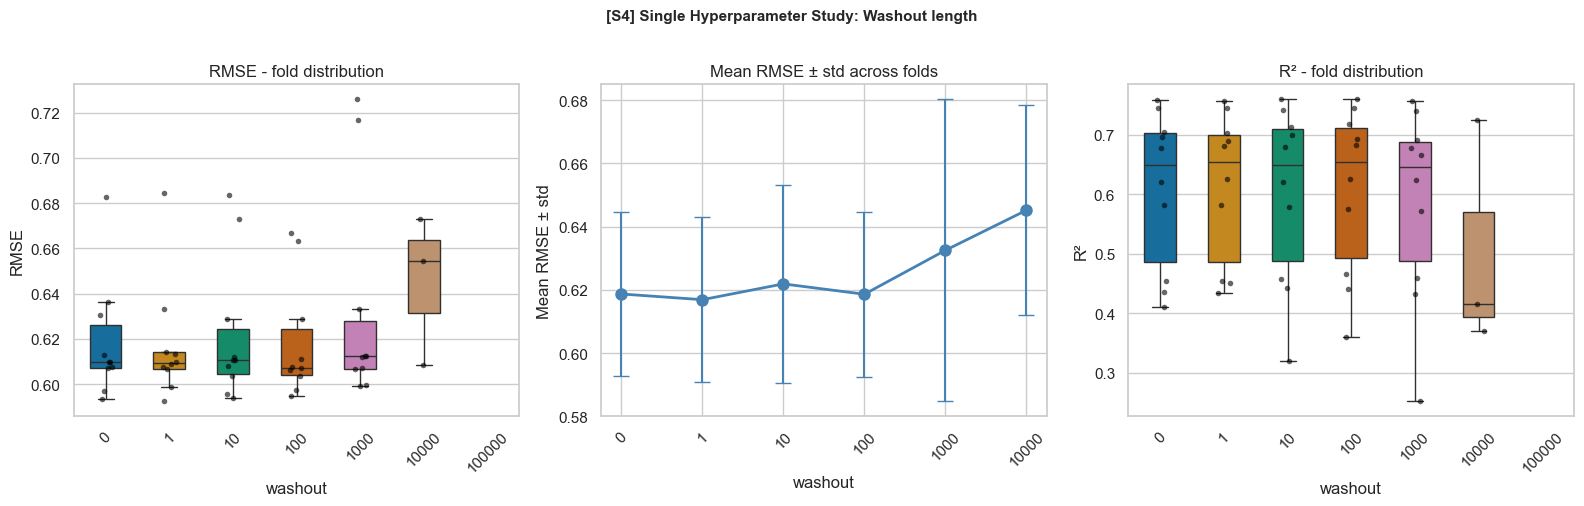

In [19]:
# Single Hyperparameter Study: Washout
washout_values = [0, 1, 10, 100, 1000, 10000, 100000]
df_shs_washout = run_single_hp_study(
    X_anchor, y_anchor, "washout", washout_values, best_params,
    save_csv=OUTPUT_DIR / "shs_washout.csv",
)
plot_single_hp(
    df_shs_washout,
    "washout",
    washout_values,
    title=f"[{ANALYSIS_SIGNAL}] Single Hyperparameter Study: Washout length",
    save_path=OUTPUT_DIR / "shs_washout.png",
)


#### 5.2.5. Sensitivity to Washout Length (washout)

Tested values: `[0, 1, 5, 10, 20, 50, 100, 200, 500]`

The washout removes the initial transient before the readout sees reservoir states.

On this benchmark, washout should be interpreted through two competing mechanisms:
- **state settling**: if the reservoir needs time to forget the initial condition, larger washout helps;
- **data starvation**: if washout is already sufficient, increasing it only discards useful training samples.

This is therefore the cleanest test of whether the benchmark difficulty comes from
true long transient dynamics or from sustained forecasting complexity.


In [20]:
# ---------------------------------------------------------------------------
# OAT sensitivity summary
# ---------------------------------------------------------------------------
def summarise_shs(df, hp_name):
    agg = (
        df.dropna(subset=["rmse"])
        .groupby(hp_name)
        .agg(
            rmse_mean=("rmse", "mean"),
            rmse_std=("rmse", "std"),
            r2_mean=("r2", "mean"),
            r2_std=("r2", "std"),
        )
        .reset_index()
        .sort_values("rmse_mean")
    )
    best_row = agg.iloc[0]
    worst_row = agg.iloc[-1]
    return {
        "parameter": hp_name,
        "best_value": best_row[hp_name],
        "best_rmse": best_row["rmse_mean"],
        "worst_value": worst_row[hp_name],
        "worst_rmse": worst_row["rmse_mean"],
        "rmse_spread": worst_row["rmse_mean"] - best_row["rmse_mean"],
        "best_r2": best_row["r2_mean"],
    }


sensitivity_summary_df = pd.DataFrame(
    [
        summarise_shs(df_shs_N, "N"),
        summarise_shs(df_shs_sr, "sr"),
        summarise_shs(df_shs_lr, "lr"),
        summarise_shs(df_shs_ridge, "ridge"),
        summarise_shs(df_shs_washout, "washout"),
    ]
).sort_values("rmse_spread", ascending=False).reset_index(drop=True)

sensitivity_summary_df.to_csv(OUTPUT_DIR / "phase_a_sensitivity_summary.csv", index=False)

print("OAT sensitivity summary on the anchor signal\n")
print(
    sensitivity_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.5f}",
    )
)


OAT sensitivity summary on the anchor signal

parameter  best_value  best_rmse   worst_value                                                                                                       worst_rmse                                                                                                      rmse_spread  best_r2
       lr     1.10000    0.64721       2.20000 3656939376580922776244261363418176176418689358358420959513161714638473496494798518577350897245193460776960.00000 3656939376580922776244261363418176176418689358358420959513161714638473496494798518577350897245193460776960.00000  0.56697
       sr     1.00000    0.61277       4.00000                                                                                                          1.18372                                                                                                          0.57095  0.61599
    ridge    10.00000    0.61248 1000000.00000                                                              

### 5.3. Refined Grid Search - Justification from the OAT study

As in Notebook 2, the OAT study is used to focus a second search on the most promising
region of the hyperparameter space.

Rather than hard-coding a new grid, we derive it directly from the OAT curves:
- keep the **top-performing `N`, `sr`, `lr`, `ridge` values**,
- keep the **top two washout values**,
- and evaluate the full Cartesian product of those OAT winners.

This preserves Notebook 2's logic while making the refined grid fully reproducible.


In [21]:
# ---------------------------------------------------------------------------
# Refined grid search anchored on the OAT winners
# ---------------------------------------------------------------------------
def top_values_from_shs(df, hp_name, k):
    ranked = (
        df.dropna(subset=["rmse"])
        .groupby(hp_name)["rmse"]
        .mean()
        .sort_values()
    )
    return sorted(list(ranked.head(k).index), key=float)


refined_grid = {
    "N":       top_values_from_shs(df_shs_N, "N", 3),
    "sr":      top_values_from_shs(df_shs_sr, "sr", 3),
    "lr":      top_values_from_shs(df_shs_lr, "lr", 3),
    "ridge":   top_values_from_shs(df_shs_ridge, "ridge", 3),
    "washout": top_values_from_shs(df_shs_washout, "washout", 2),
}

refined_configs = list(ParameterGrid(refined_grid))
print("Refined grid")
print("------------")
for key, values in refined_grid.items():
    print(f"  {key:8s}: {values}")
print(f"\nConfigurations : {len(refined_configs)}")
print(f"Total model fits: {len(refined_configs) * N_SPLITS}")

df_refined = run_esn_cv_search(X_anchor, y_anchor, refined_configs, signal_name=ANALYSIS_SIGNAL)
agg_refined = aggregate_phase_a(df_refined)
agg_refined.to_csv(OUTPUT_DIR / "refined_grid_results.csv", index=False)

print("\nTop 10 refined-grid configurations\n")
display_cols = ["N", "sr", "lr", "ridge", "washout", "rmse_mean", "rmse_std", "r2_mean", "r2_std"]
print(agg_refined[display_cols].head(10).to_string(index=False, float_format=lambda x: f"{x:.5f}"))

best_refined = agg_refined.iloc[0]
best_params_refined = params_from_row(best_refined)
best_model_params = best_params_refined.copy()

print(f"\nBest refined configuration for {ANALYSIS_SIGNAL}: {best_model_params}")
print(f"  RMSE = {best_refined['rmse_mean']:.5f} ± {best_refined['rmse_std']:.5f}")
print(f"  R²   = {best_refined['r2_mean']:.5f} ± {best_refined['r2_std']:.5f}")


Refined grid
------------
  N       : [40, 80, 160]
  sr      : [0.1, 0.5, 1.0]
  lr      : [1.1, 1.2, 1.3]
  ridge   : [0.1, 1.0, 10.0]
  washout : [1, 100]

Configurations : 162
Total model fits: 1620
    [S4]   1/162 configs | elapsed=0.0 min | rate=8.59 eval/s
    [S4]  20/162 configs | elapsed=0.4 min | rate=8.47 eval/s
    [S4]  40/162 configs | elapsed=0.8 min | rate=8.42 eval/s
    [S4]  60/162 configs | elapsed=1.2 min | rate=8.25 eval/s
    [S4]  80/162 configs | elapsed=1.7 min | rate=8.01 eval/s
    [S4] 100/162 configs | elapsed=2.1 min | rate=7.80 eval/s
    [S4] 120/162 configs | elapsed=2.9 min | rate=6.89 eval/s
    [S4] 140/162 configs | elapsed=3.6 min | rate=6.55 eval/s
    [S4] 160/162 configs | elapsed=4.2 min | rate=6.36 eval/s

Top 10 refined-grid configurations

  N      sr      lr    ridge  washout  rmse_mean  rmse_std  r2_mean  r2_std
160 0.50000 1.10000 10.00000        1    0.63856   0.01652  0.58277 0.13863
160 0.50000 1.10000 10.00000      100    0.64128  

### 5.4. Best-Model Prediction on the Anchor Benchmark Signal

The refined best configuration is now trained on the first 75 % of the anchor signal and
evaluated on the remaining 25 %, exactly as in Notebook 2. This gives a direct visual check
of whether the tuned ESN tracks both the fine oscillatory structure and the slower
modulation envelope.


Figure saved → single_hp_outputs_4/best_model_prediction.png


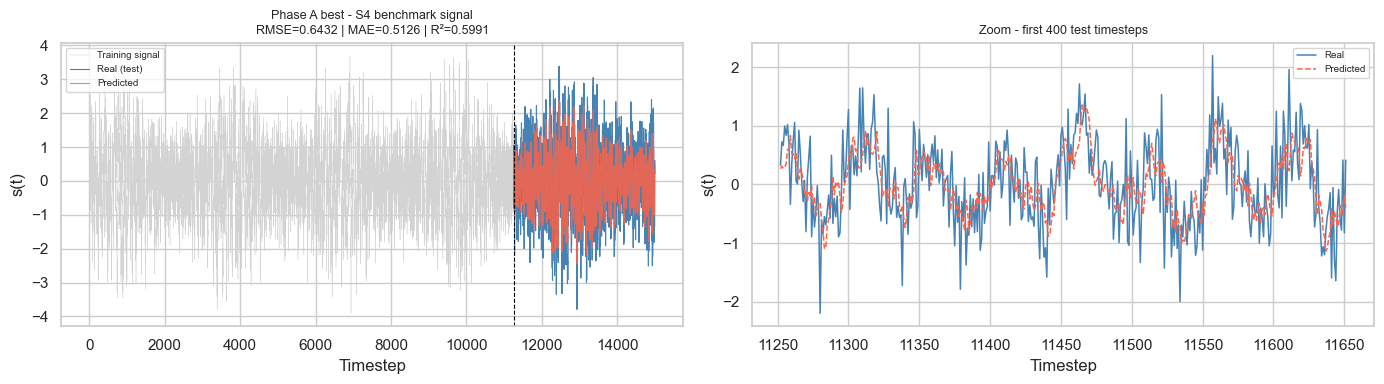


Held-out test metrics on the anchor signal (S4)
  RMSE = 0.64315
  MAE  = 0.51260
  R²   = 0.59911

Held-out summary on the core benchmark signals

signal   N      sr      lr    ridge  washout  rmse_holdout  mae_holdout  r2_holdout
    S1 200 1.10000 0.10000  0.10000       20       0.13382      0.10672     0.97482
    S2 200 1.10000 0.05000  0.10000       50       0.24204      0.19105     0.92396
    S3 200 1.10000 0.10000  0.10000       20       0.42692      0.33982     0.77819
    S4 160 0.50000 1.10000 10.00000        1       0.64303      0.51496     0.59926


In [22]:
# ---------------------------------------------------------------------------
# Best-model prediction on the anchor signal + holdout summary on S1-S4
# ---------------------------------------------------------------------------
metrics_anchor = plot_signal_prediction(
    ANALYSIS_SIGNAL,
    anchor_cfg,
    best_model_params,
    title=f"Phase A best - {ANALYSIS_SIGNAL} benchmark signal",
    save_path=OUTPUT_DIR / "best_model_prediction.png",
)

print(f"\nHeld-out test metrics on the anchor signal ({ANALYSIS_SIGNAL})")
print(f"  RMSE = {metrics_anchor['rmse']:.5f}")
print(f"  MAE  = {metrics_anchor['mae']:.5f}")
print(f"  R²   = {metrics_anchor['r2']:.5f}")

holdout_rows = []
for sig_name in CORE_SIGNALS:
    params_here = best_params_refined if sig_name == ANALYSIS_SIGNAL else BEST_PARAMS_PER_SIGNAL[sig_name]
    metrics_here = evaluate_holdout_prediction(SIGNALS[sig_name]["data"], params_here)
    holdout_rows.append(
        {
            "signal": sig_name,
            "N": params_here["N"],
            "sr": params_here["sr"],
            "lr": params_here["lr"],
            "ridge": params_here["ridge"],
            "washout": params_here["washout"],
            "rmse_holdout": metrics_here["rmse"],
            "mae_holdout": metrics_here["mae"],
            "r2_holdout": metrics_here["r2"],
        }
    )

holdout_core_df = pd.DataFrame(holdout_rows).sort_values("signal").reset_index(drop=True)
holdout_core_df.to_csv(OUTPUT_DIR / "core_signals_holdout_summary.csv", index=False)

print("\nHeld-out summary on the core benchmark signals\n")
print(holdout_core_df.to_string(index=False, float_format=lambda x: f"{x:.5f}"))


<br>

---

## 6. Phase B - Reservoir Topology Study

We now fix the best-performing Phase A hyperparameters and reproduce Notebook 2's
**reservoir topology study** on the anchor signal.

The three graph families are the same:

| Topology | Graph model | Structural parameter(s) |
|----------|-------------|-------------------------|
| **ER** | Erdős-Rényi | `p` - edge probability |
| **WS** | Watts-Strogatz | `k` - ring neighbours, `p_rewire` - rewiring probability |
| **BA** | Barabási-Albert | `m` - edges per new node |

As in Notebook 2, the purpose is to isolate how **density**, **degree structure**, and
**natural spectral radius** alter the benchmark performance once the ESN hyperparameters are fixed.


In [23]:
# ---------------------------------------------------------------------------
# Reservoir topology helpers
# ---------------------------------------------------------------------------
PHASE_B_PARAMS = best_model_params.copy()


def make_reservoir_matrix(N, topology, topo_params):

    if topology == "random":
        G = nx.erdos_renyi_graph(N, topo_params["p"], directed=True)
    elif topology == "small_world":
        k = int(topo_params["k"])
        if k % 2 != 0:
            k += 1
        k = min(max(k, 2), N - 1)
        G = nx.watts_strogatz_graph(N, k, p=topo_params["p_rewire"]).to_directed()
    elif topology == "scale_free":
        m = max(1, min(int(topo_params["m"]), N - 1))
        G = nx.barabasi_albert_graph(N, m).to_directed()
    else:
        raise ValueError(f"Unknown topology: {topology}")

    A = nx.adjacency_matrix(G).toarray().astype(np.float64)
    mask = A > 0
    W = np.zeros_like(A)
    if mask.any():
        W[mask] = rng.randn(mask.sum())
    else:
        W = rng.randn(N, N) * 0.01
        mask = W != 0

    spectral_radius = float(np.max(np.abs(np.linalg.eigvals(W))))
    info = {
        "topology": topology,
        "N": N,
        "actual_density": mask.sum() / (N * N),
        "avg_degree": mask.sum(axis=1).mean(),
        "spectral_radius": spectral_radius,
        "n_edges": int(mask.sum()),
    }
    return W, info


def run_topology_shs(X, y, topology, param_name, param_values, esn_params, fixed_topo=None, n_splits=N_SPLITS, save_csv=None):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fixed_topo = fixed_topo or {}
    records = []

    print(
        f"Topology SHS [{topology}] '{param_name}': {len(param_values)} values x {n_splits} folds"
    )

    for val in param_values:
        topo_params = {**fixed_topo, param_name: val}
        try:
            W, info = make_reservoir_matrix(esn_params["N"], topology, topo_params)
        except Exception as exc:
            print(f"  [MATRIX ERROR] {param_name}={val}: {exc}")
            for fold_idx in range(n_splits):
                records.append(
                    {
                        param_name: val,
                        "fold": fold_idx,
                        "rmse": np.nan,
                        "mae": np.nan,
                        "r2": np.nan,
                        "train_time_s": np.nan,
                        "density": np.nan,
                        "sr": np.nan,
                    }
                )
            continue

        for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X)):
            X_tr_f, y_tr_f = X[train_idx], y[train_idx]
            X_te_f, y_te_f = X[test_idx], y[test_idx]

            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr_f)
            X_te = scaler.transform(X_te_f)

            try:
                t0 = time.time()
                reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
                model = reservoir >> Ridge(ridge=esn_params["ridge"])
                model.fit(X_tr, y_tr_f, warmup=int(esn_params["washout"]))
                y_pred = np.asarray(model.run(X_te)).reshape(-1)
                y_true = y_te_f.ravel()

                records.append(
                    {
                        param_name: val,
                        "fold": fold_idx,
                        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
                        "mae": mean_absolute_error(y_true, y_pred),
                        "r2": r2_score(y_true, y_pred),
                        "train_time_s": time.time() - t0,
                        "density": info["actual_density"],
                        "sr": info["spectral_radius"],
                    }
                )
            except Exception as exc:
                print(f"  [ERROR] {param_name}={val}, fold {fold_idx}: {exc}")
                records.append(
                    {
                        param_name: val,
                        "fold": fold_idx,
                        "rmse": np.nan,
                        "mae": np.nan,
                        "r2": np.nan,
                        "train_time_s": np.nan,
                        "density": np.nan,
                        "sr": np.nan,
                    }
                )

    df_out = pd.DataFrame(records)
    if save_csv is not None:
        df_out.to_csv(save_csv, index=False)
        print(f"  CSV saved → {save_csv}")
    return df_out


print(f"Phase B parameters fixed to: {PHASE_B_PARAMS}")


Phase B parameters fixed to: {'N': 160, 'sr': 0.5, 'lr': 1.1, 'ridge': 10.0, 'washout': 1}


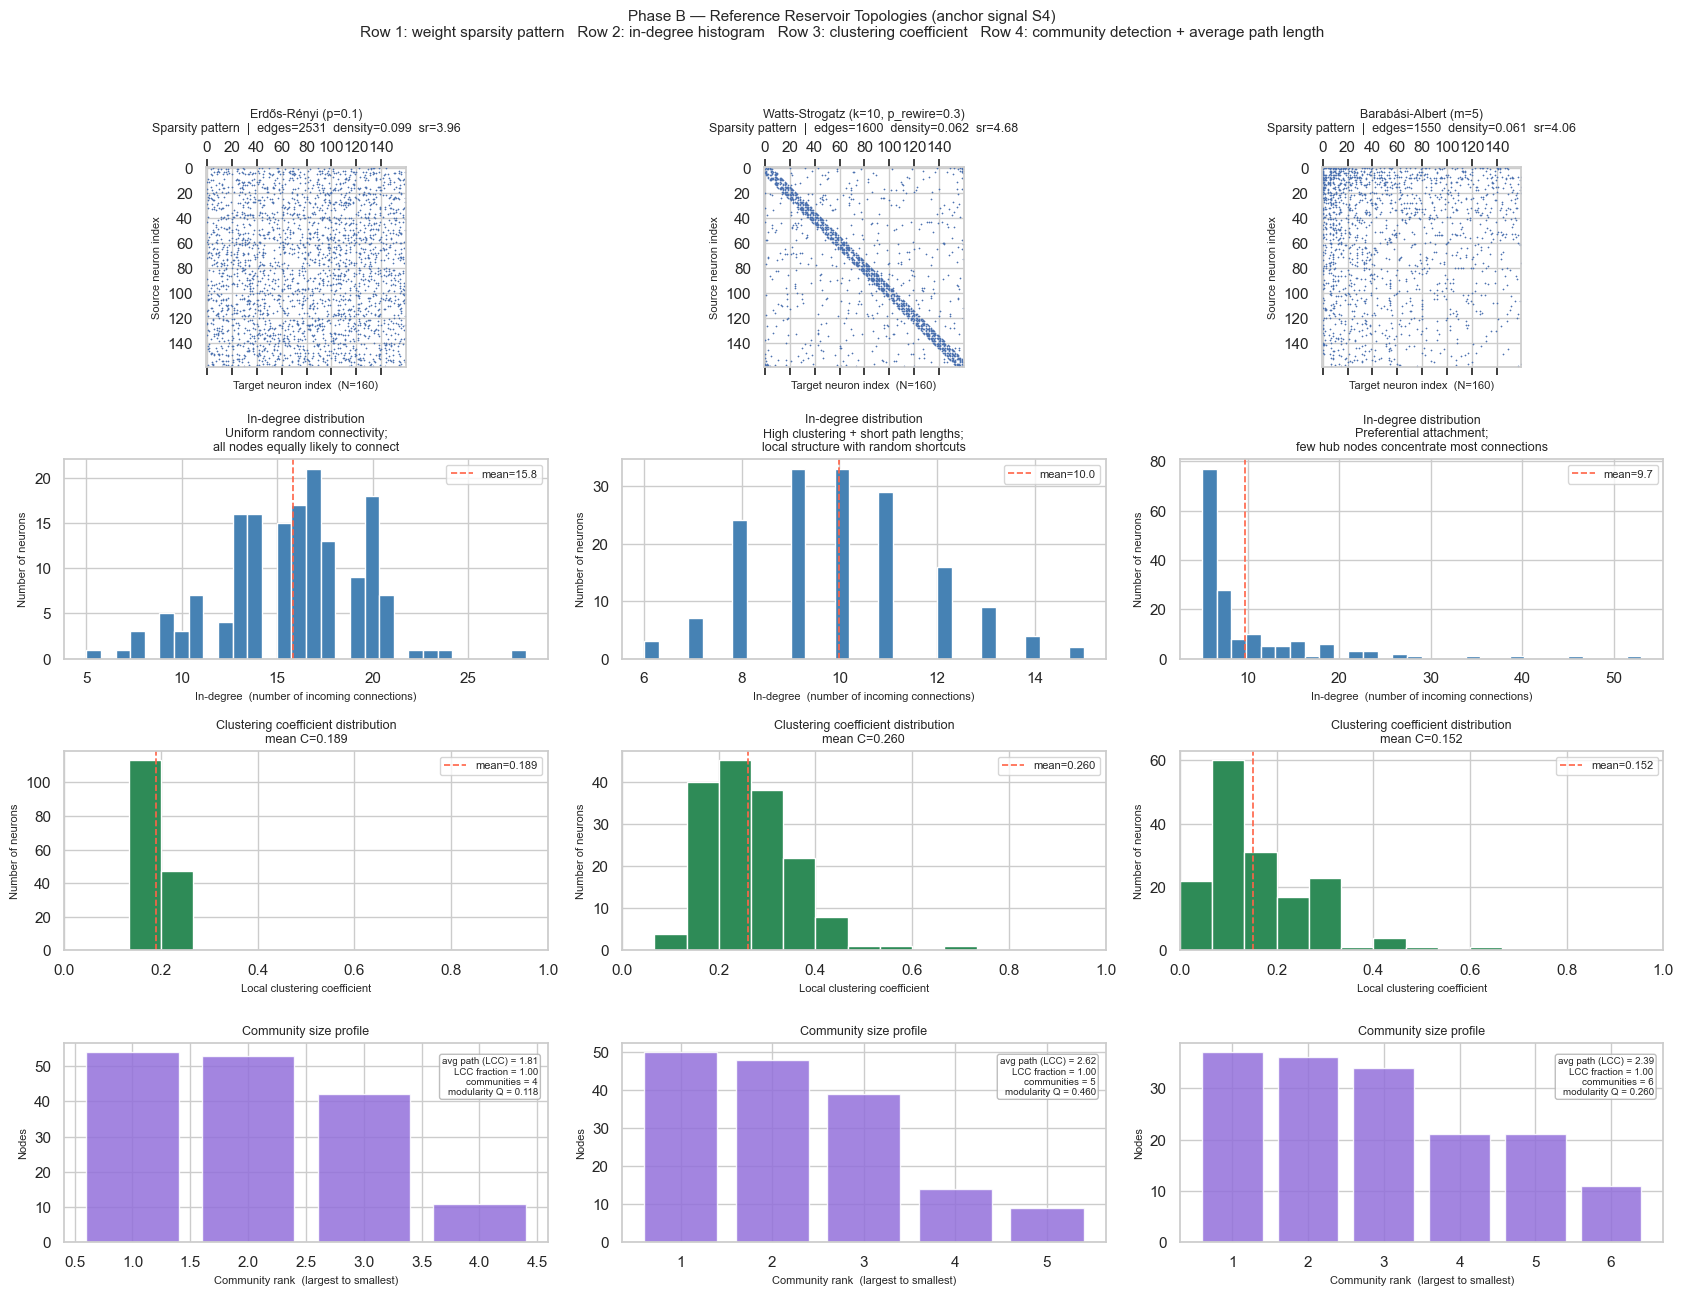

Figure saved → single_hp_outputs_4/phase_b_topology_overview.png
Metrics saved → single_hp_outputs_4/phase_b_topology_graph_metrics.csv

Reference topology graph metrics:

                           Topology  density  spectral_radius  mean_in_degree  avg_clustering  avg_path_lcc  lcc_ratio  n_communities  modularity
                Erdős-Rényi (p=0.1)   0.0989           3.9637         15.8187          0.1893        1.8112     1.0000              4      0.1184
Watts-Strogatz (k=10, p_rewire=0.3)   0.0625           4.6839         10.0000          0.2601        2.6190     1.0000              5      0.4599
              Barabási-Albert (m=5)   0.0605           4.0569          9.6875          0.1516        2.3854     1.0000              6      0.2603


In [34]:
# ---------------------------------------------------------------------------
# Visualise reference weight matrices and graph diagnostics
# ---------------------------------------------------------------------------
ref_params = {
    "random":      {"p": 0.1},
    "small_world": {"k": min(10, PHASE_B_PARAMS["N"] - 1), "p_rewire": 0.3},
    "scale_free":  {"m": max(1, min(5, PHASE_B_PARAMS["N"] - 1))},
}
topologies = list(ref_params.keys())

topo_labels = {
    "random": f"Erdős-Rényi (p={ref_params['random']['p']})",
    "small_world": (
        f"Watts-Strogatz (k={ref_params['small_world']['k']}, "
        f"p_rewire={ref_params['small_world']['p_rewire']})"
    ),
    "scale_free": f"Barabási-Albert (m={ref_params['scale_free']['m']})",
}
topo_descriptions = {
    "random":      "Uniform random connectivity;\nall nodes equally likely to connect",
    "small_world": "High clustering + short path lengths;\nlocal structure with random shortcuts",
    "scale_free":  "Preferential attachment;\nfew hub nodes concentrate most connections",
}

W_dict = {}
metrics_rows = []
fig, axes = plt.subplots(4, 3, figsize=(17, 13))

for i, topo in enumerate(topologies):
    W, info = make_reservoir_matrix(PHASE_B_PARAMS["N"], topo, ref_params[topo])
    W_dict[topo] = W

    mask = (W != 0)
    mask_int = mask.astype(int)
    n_nodes = W.shape[0]
    n_edges = int(mask.sum())
    density = n_edges / (n_nodes ** 2)
    in_deg = mask.sum(axis=0)
    spectral_radius = float(np.max(np.abs(np.linalg.eigvals(W))))

    # Use the undirected projection for clustering, path length, and communities.
    # This is the standard view when checking the small-world property.
    G_und = nx.from_numpy_array(np.maximum(mask_int, mask_int.T))

    clustering_local = np.array(list(nx.clustering(G_und).values()), dtype=float)
    avg_clustering = float(clustering_local.mean()) if clustering_local.size else np.nan

    if G_und.number_of_edges() > 0 and G_und.number_of_nodes() > 1:
        largest_nodes = max(nx.connected_components(G_und), key=len)
        G_lcc = G_und.subgraph(largest_nodes).copy()
        lcc_ratio = G_lcc.number_of_nodes() / G_und.number_of_nodes()
        avg_path = (
            float(nx.average_shortest_path_length(G_lcc))
            if G_lcc.number_of_nodes() > 1 else np.nan
        )
        communities = list(nx.community.greedy_modularity_communities(G_und))
        modularity = (
            float(nx.community.modularity(G_und, communities))
            if len(communities) > 1 else 0.0
        )
        comm_sizes = sorted((len(c) for c in communities), reverse=True)
    else:
        lcc_ratio = np.nan
        avg_path = np.nan
        modularity = np.nan
        comm_sizes = [1] * G_und.number_of_nodes()

    avg_path_str = f"{avg_path:.2f}" if np.isfinite(avg_path) else "n/a"
    lcc_ratio_str = f"{lcc_ratio:.2f}" if np.isfinite(lcc_ratio) else "n/a"
    modularity_str = f"{modularity:.3f}" if np.isfinite(modularity) else "n/a"

    metrics_rows.append({
        "Topology": topo_labels[topo],
        "density": density,
        "spectral_radius": spectral_radius,
        "mean_in_degree": float(in_deg.mean()),
        "avg_clustering": avg_clustering,
        "avg_path_lcc": avg_path,
        "lcc_ratio": lcc_ratio,
        "n_communities": len(comm_sizes),
        "modularity": modularity,
    })

    ax = axes[0, i]
    ax.spy(mask, markersize=0.3, aspect="equal")
    ax.set_title(
        f"{topo_labels[topo]}\n"
        f"Sparsity pattern  |  edges={n_edges}  density={density:.3f}  sr={spectral_radius:.2f}",
        fontsize=9, pad=6
    )
    ax.set_xlabel(f"Target neuron index  (N={n_nodes})", fontsize=8)
    ax.set_ylabel("Source neuron index", fontsize=8)

    ax = axes[1, i]
    ax.hist(in_deg, bins=30, color="steelblue", edgecolor="white")
    ax.set_xlabel("In-degree  (number of incoming connections)", fontsize=8)
    ax.set_ylabel("Number of neurons", fontsize=8)
    ax.set_title(
        f"In-degree distribution\n{topo_descriptions[topo]}",
        fontsize=9, pad=6
    )
    ax.axvline(
        in_deg.mean(), color="tomato", linestyle="--", linewidth=1.2,
        label=f"mean={in_deg.mean():.1f}"
    )
    ax.legend(fontsize=8)

    ax = axes[2, i]
    ax.hist(clustering_local, bins=np.linspace(0, 1, 16), color="seagreen", edgecolor="white")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Local clustering coefficient", fontsize=8)
    ax.set_ylabel("Number of neurons", fontsize=8)
    ax.set_title(
        f"Clustering coefficient distribution\nmean C={avg_clustering:.3f}",
        fontsize=9, pad=6
    )
    ax.axvline(
        avg_clustering, color="tomato", linestyle="--", linewidth=1.2,
        label=f"mean={avg_clustering:.3f}"
    )
    ax.legend(fontsize=8)

    ax = axes[3, i]
    top_sizes = comm_sizes[:10]
    ax.bar(np.arange(1, len(top_sizes) + 1), top_sizes, color="mediumpurple", alpha=0.85)
    ax.set_xlabel("Community rank  (largest to smallest)", fontsize=8)
    ax.set_ylabel("Nodes", fontsize=8)
    ax.set_title("Community size profile", fontsize=9, pad=6)
    if len(comm_sizes) > len(top_sizes):
        ax.text(0.98, 0.95, f"top {len(top_sizes)} of {len(comm_sizes)}",
                transform=ax.transAxes, ha="right", va="top", fontsize=7)
    ax.text(
        0.98, 0.93,
        f"avg path (LCC) = {avg_path_str}\n"
        f"LCC fraction = {lcc_ratio_str}\n"
        f"communities = {len(comm_sizes)}\n"
        f"modularity Q = {modularity_str}",
        transform=ax.transAxes,
        ha="right", va="top", fontsize=7,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85, edgecolor="0.7")
    )

fig.suptitle(
    f"Phase B — Reference Reservoir Topologies (anchor signal {ANALYSIS_SIGNAL})\n"
    "Row 1: weight sparsity pattern   Row 2: in-degree histogram   "
    "Row 3: clustering coefficient   Row 4: community detection + average path length",
    fontsize=11, y=0.995
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUTPUT_DIR / "phase_b_topology_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {OUTPUT_DIR / 'phase_b_topology_overview.png'}")

df_topology_graph = pd.DataFrame(metrics_rows)
df_topology_graph.to_csv(OUTPUT_DIR / "phase_b_topology_graph_metrics.csv", index=False)
print(f"Metrics saved → {OUTPUT_DIR / 'phase_b_topology_graph_metrics.csv'}")

print()
print("Reference topology graph metrics:")
print()
print(
    df_topology_graph[
        [
            "Topology", "density", "spectral_radius", "mean_in_degree",
            "avg_clustering", "avg_path_lcc", "lcc_ratio",
            "n_communities", "modularity",
        ]
    ].to_string(index=False, float_format="%.4f")
)


The four rows above extend the qualitative topology check with graph-theoretic diagnostics:

- the **sparsity pattern** and **in-degree histogram** show how recurrent connectivity is allocated,
- the **local clustering coefficient distribution** measures triangle-rich local structure,
- the **average shortest-path length on the largest connected component** checks whether short paths coexist with clustering, i.e. the small-world property,
- the **community size profile** and **modularity-based detection** show whether each reservoir decomposes into mesoscopic modules.

This provides direct structural context for the RMSE and R² topology sweeps that follow, and the numeric summary is exported alongside the figure for later inspection.


Topology SHS [random] 'p': 5 values x 10 folds
  CSV saved → single_hp_outputs_4/topo_random_p.csv
  Figure saved → single_hp_outputs_4/shs_p.png


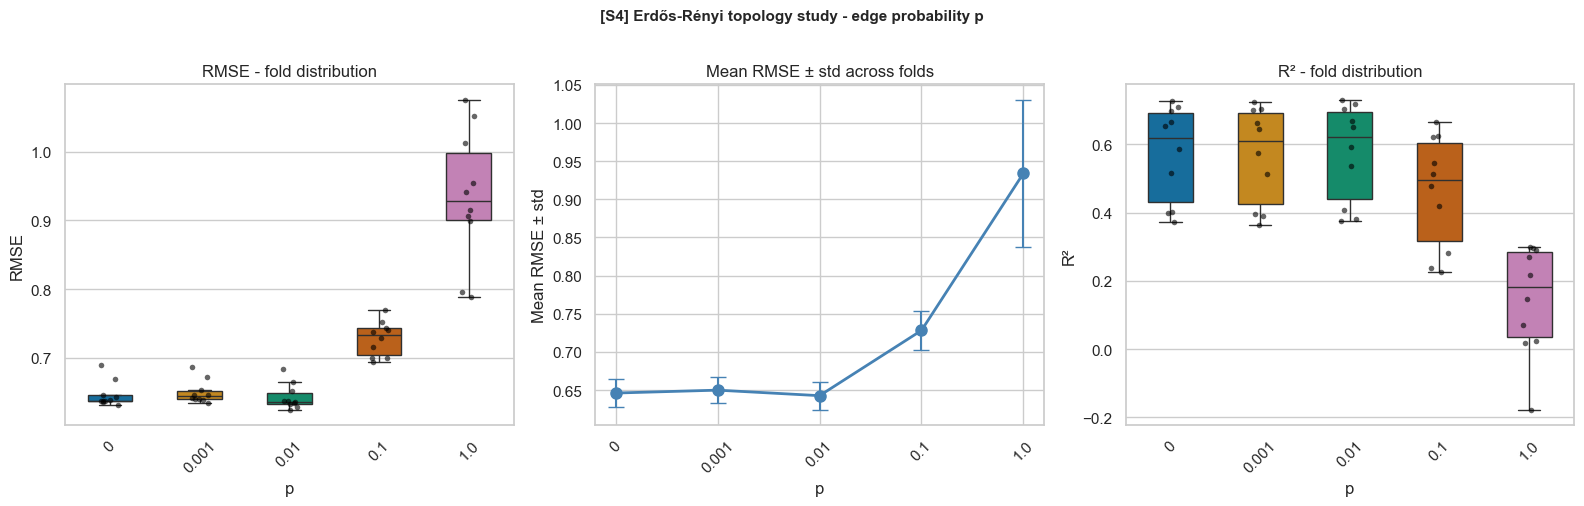

In [ ]:
# ---------------------------------------------------------------------------
# 6.1 Erdős-Rényi - sensitivity to edge probability p
# ---------------------------------------------------------------------------
er_p_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

df_shs_er_p = run_topology_shs(
    X_anchor,
    y_anchor,
    topology="random",
    param_name="p",
    param_values=er_p_values,
    esn_params=PHASE_B_PARAMS,
    save_csv=OUTPUT_DIR / "topo_random_p.csv",
)

plot_single_hp(
    df_shs_er_p,
    "p",
    er_p_values,
    title=f"[{ANALYSIS_SIGNAL}] Erdős-Rényi topology study - edge probability p",
    save_path=OUTPUT_DIR / "shs_p.png",
)

Topology SHS [random] 'p': 11 values x 10 folds
  CSV saved → single_hp_outputs_4/topo_random_p.csv
  Figure saved → single_hp_outputs_4/shs_p.png


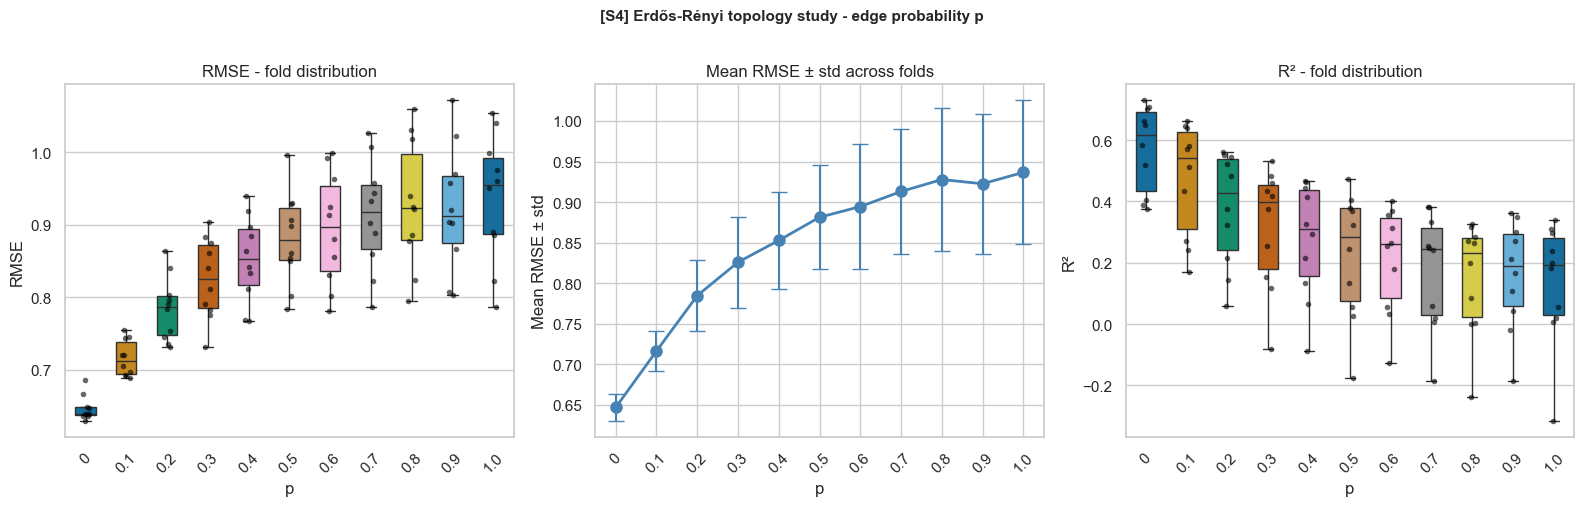

In [ ]:
# ---------------------------------------------------------------------------
# 6.1 Erdős-Rényi - sensitivity to edge probability p
# ---------------------------------------------------------------------------
er_p_values = [0, 0.001, 0.01, 0.1, 1.0]

df_shs_er_p = run_topology_shs(
    X_anchor,
    y_anchor,
    topology="random",
    param_name="p",
    param_values=er_p_values,
    esn_params=PHASE_B_PARAMS,
    save_csv=OUTPUT_DIR / "topo_random_p.csv",
)

plot_single_hp(
    df_shs_er_p,
    "p",
    er_p_values,
    title=f"[{ANALYSIS_SIGNAL}] Erdős-Rényi topology study - edge probability p",
    save_path=OUTPUT_DIR / "shs_p.png",
)

#### 6.1. Erdős-Rényi (Random) - Sensitivity to Edge Probability (p)

This sweep isolates the effect of **reservoir density** in the most neutral topology family.

Interpretation guide:
- if performance degrades monotonically with `p`, the anchor signal prefers sparse reservoirs;
- if there is a broad plateau, density is largely irrelevant in that regime;
- if a dense regime reappears as competitive, the benchmark may be entering a different
  random-matrix operating mode.


Topology SHS [small_world] 'k': 9 values x 10 folds
  CSV saved → single_hp_outputs_4/topo_small_world_k.csv
  Figure saved → single_hp_outputs_4/shs_k.png


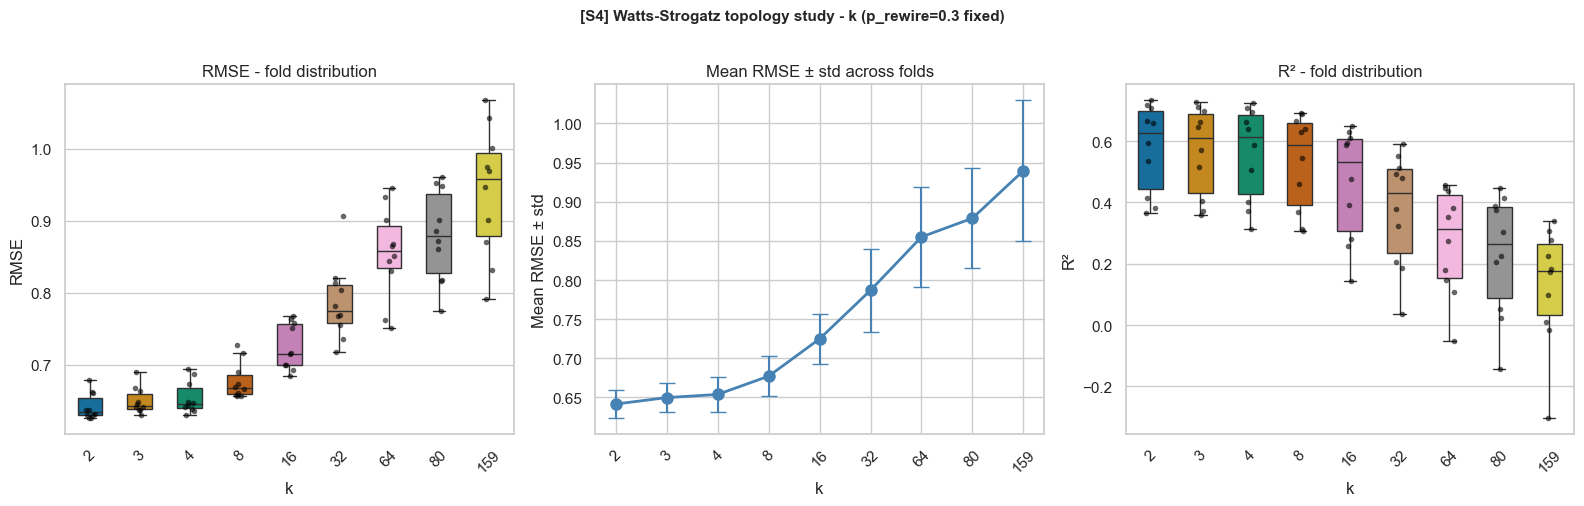

In [27]:
# ---------------------------------------------------------------------------
# 6.2a Watts-Strogatz - sensitivity to ring neighbours k
# ---------------------------------------------------------------------------
ws_k_values = sorted(
    {
        v
        for v in [2, 3, 4, 8, 16, 32, 64, PHASE_B_PARAMS["N"] // 2, PHASE_B_PARAMS["N"] - 1]
        if 1 < v < PHASE_B_PARAMS["N"]
    }
)
FIXED_P_REWIRE = 0.3

df_shs_ws_k = run_topology_shs(
    X_anchor,
    y_anchor,
    topology="small_world",
    param_name="k",
    param_values=ws_k_values,
    esn_params=PHASE_B_PARAMS,
    fixed_topo={"p_rewire": FIXED_P_REWIRE},
    save_csv=OUTPUT_DIR / "topo_small_world_k.csv",
)

plot_single_hp(
    df_shs_ws_k,
    "k",
    ws_k_values,
    label_map={v: str(v) for v in ws_k_values},
    title=f"[{ANALYSIS_SIGNAL}] Watts-Strogatz topology study - k (p_rewire={FIXED_P_REWIRE} fixed)",
    save_path=OUTPUT_DIR / "shs_k.png",
)


Topology SHS [small_world] 'p_rewire': 11 values x 10 folds
  CSV saved → single_hp_outputs_4/topo_small_world_p_rewire_k10.csv
  Figure saved → single_hp_outputs_4/shs_p_rewire_k10.png


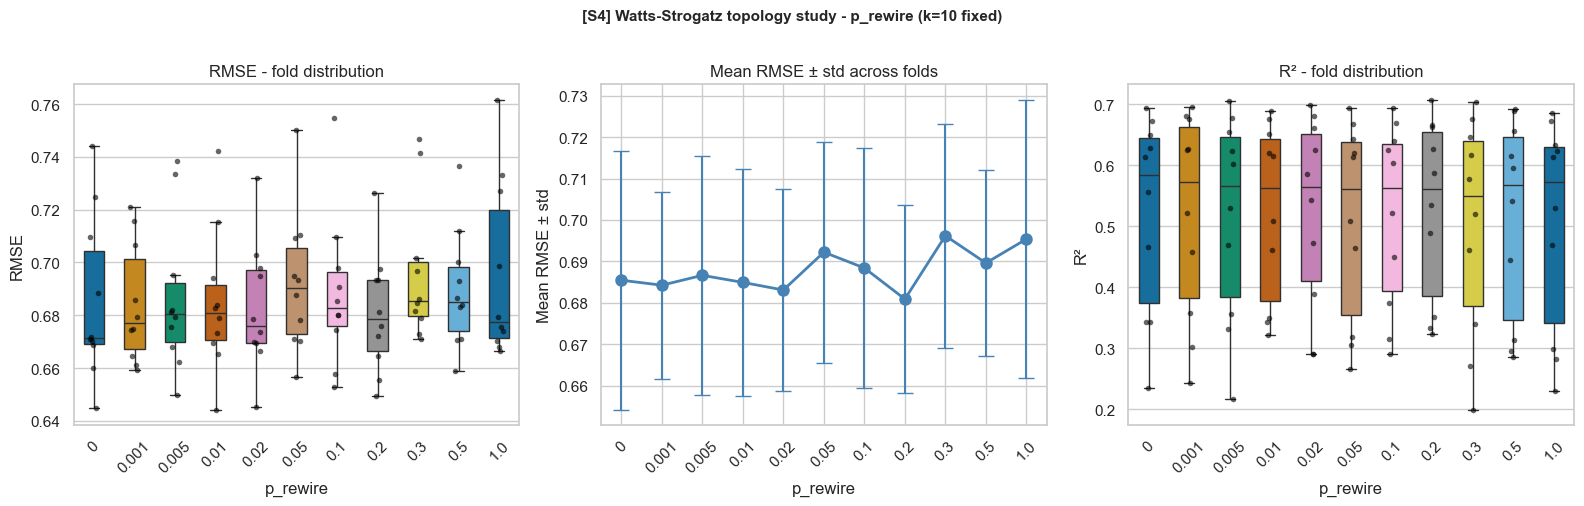

In [28]:
# ---------------------------------------------------------------------------
# 6.2b Watts-Strogatz - sensitivity to p_rewire at low k
# ---------------------------------------------------------------------------
ws_prw_values = [0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
FIXED_K_LOW = min(10, PHASE_B_PARAMS["N"] - 1)

df_shs_ws_prw_low = run_topology_shs(
    X_anchor,
    y_anchor,
    topology="small_world",
    param_name="p_rewire",
    param_values=ws_prw_values,
    esn_params=PHASE_B_PARAMS,
    fixed_topo={"k": FIXED_K_LOW},
    save_csv=OUTPUT_DIR / f"topo_small_world_p_rewire_k{FIXED_K_LOW}.csv",
)

plot_single_hp(
    df_shs_ws_prw_low,
    "p_rewire",
    ws_prw_values,
    label_map={v: str(v) for v in ws_prw_values},
    title=f"[{ANALYSIS_SIGNAL}] Watts-Strogatz topology study - p_rewire (k={FIXED_K_LOW} fixed)",
    save_path=OUTPUT_DIR / f"shs_p_rewire_k{FIXED_K_LOW}.png",
)


Topology SHS [small_world] 'p_rewire': 11 values x 10 folds
  CSV saved → single_hp_outputs_4/topo_small_world_p_rewire_k16.csv
  Figure saved → single_hp_outputs_4/shs_p_rewire_k16.png


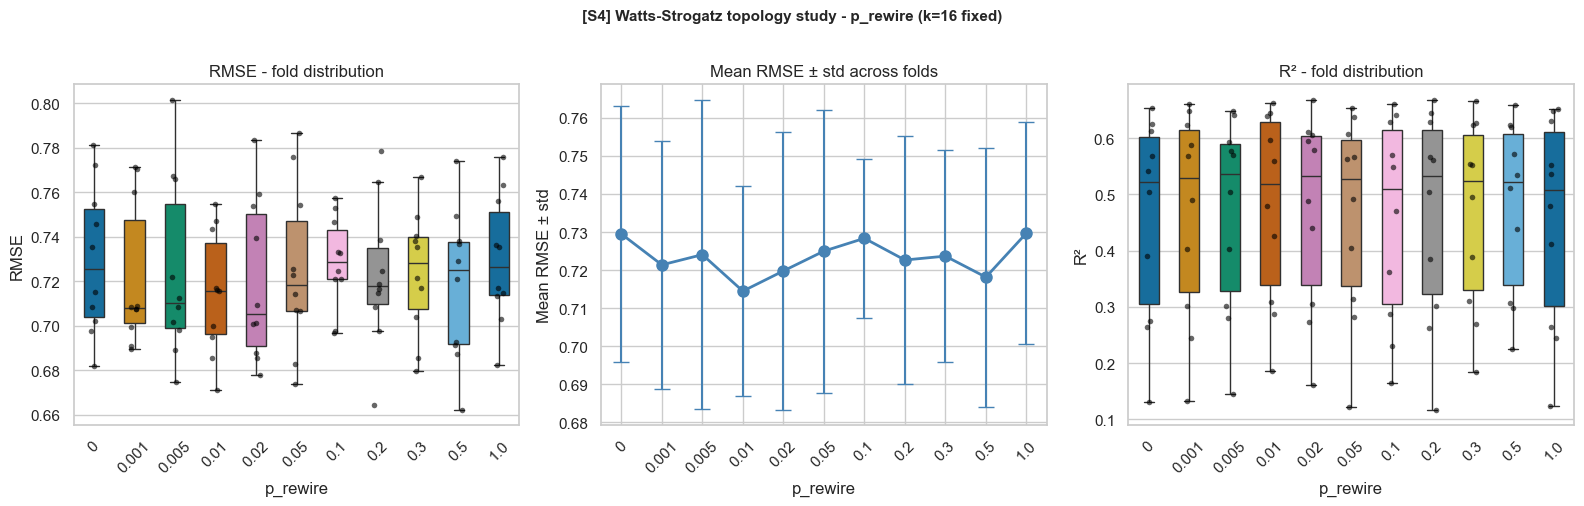

In [29]:
# ---------------------------------------------------------------------------
# 6.2c Watts-Strogatz - sensitivity to p_rewire at higher k
# ---------------------------------------------------------------------------
FIXED_K_HIGH = min(max(16, FIXED_K_LOW + 2), PHASE_B_PARAMS["N"] - 1)

if FIXED_K_HIGH == FIXED_K_LOW:
    print(f"High-k sweep collapses to k={FIXED_K_LOW}; reusing the low-k rewiring study.")
    df_shs_ws_prw_high = df_shs_ws_prw_low.copy()
else:
    df_shs_ws_prw_high = run_topology_shs(
        X_anchor,
        y_anchor,
        topology="small_world",
        param_name="p_rewire",
        param_values=ws_prw_values,
        esn_params=PHASE_B_PARAMS,
        fixed_topo={"k": FIXED_K_HIGH},
        save_csv=OUTPUT_DIR / f"topo_small_world_p_rewire_k{FIXED_K_HIGH}.csv",
    )

    plot_single_hp(
        df_shs_ws_prw_high,
        "p_rewire",
        ws_prw_values,
        label_map={v: str(v) for v in ws_prw_values},
        title=f"[{ANALYSIS_SIGNAL}] Watts-Strogatz topology study - p_rewire (k={FIXED_K_HIGH} fixed)",
        save_path=OUTPUT_DIR / f"shs_p_rewire_k{FIXED_K_HIGH}.png",
    )


#### 6.2. Watts-Strogatz (Small-world) - Sensitivity to `k` and `p_rewire`

The Watts-Strogatz family separates two structural questions:

- **How many recurrent neighbours does each node have?** (`k`)
- **How random is the graph once that neighbourhood size is fixed?** (`p_rewire`)

This lets us distinguish whether performance is controlled mainly by:
- **density** (`k`), or
- **small-world rewiring structure** (`p_rewire`).

Running the rewiring sweep at both **lower** and **higher** `k` values keeps the analysis
as detailed as Notebook 2 and makes it possible to see whether rewiring only matters once
the reservoir is already moderately dense.


Topology SHS [scale_free] 'm': 8 values x 10 folds
  CSV saved → single_hp_outputs_4/topo_scale_free_m.csv
  Figure saved → single_hp_outputs_4/shs_m.png


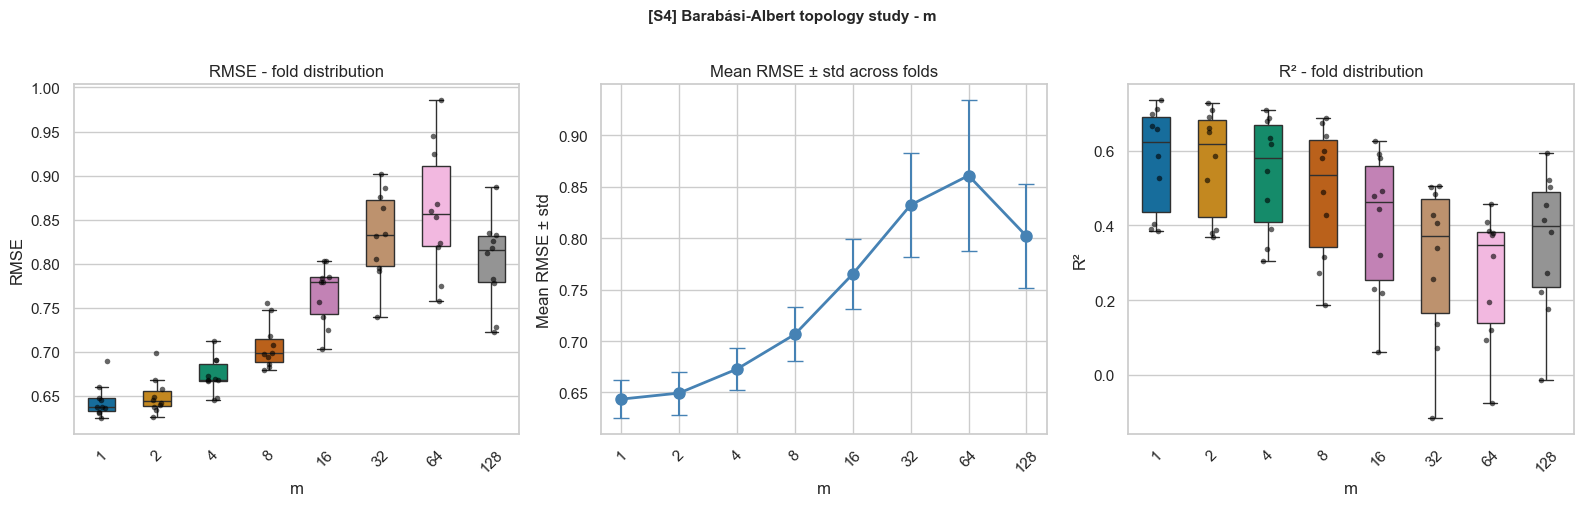

In [30]:
# ---------------------------------------------------------------------------
# 6.3 Barabási-Albert - sensitivity to m
# ---------------------------------------------------------------------------
ba_m_values = []
m_val = 1
while m_val < PHASE_B_PARAMS["N"]:
    ba_m_values.append(m_val)
    m_val *= 2

df_shs_ba_m = run_topology_shs(
    X_anchor,
    y_anchor,
    topology="scale_free",
    param_name="m",
    param_values=ba_m_values,
    esn_params=PHASE_B_PARAMS,
    save_csv=OUTPUT_DIR / "topo_scale_free_m.csv",
)

plot_single_hp(
    df_shs_ba_m,
    "m",
    ba_m_values,
    label_map={v: str(v) for v in ba_m_values},
    title=f"[{ANALYSIS_SIGNAL}] Barabási-Albert topology study - m",
    save_path=OUTPUT_DIR / "shs_m.png",
)


Topology SHS [scale_free] 'm': 8 values x 10 folds
  CSV saved → single_hp_outputs_4/topo_scale_free_m.csv
  Figure saved → single_hp_outputs_4/shs_m.png


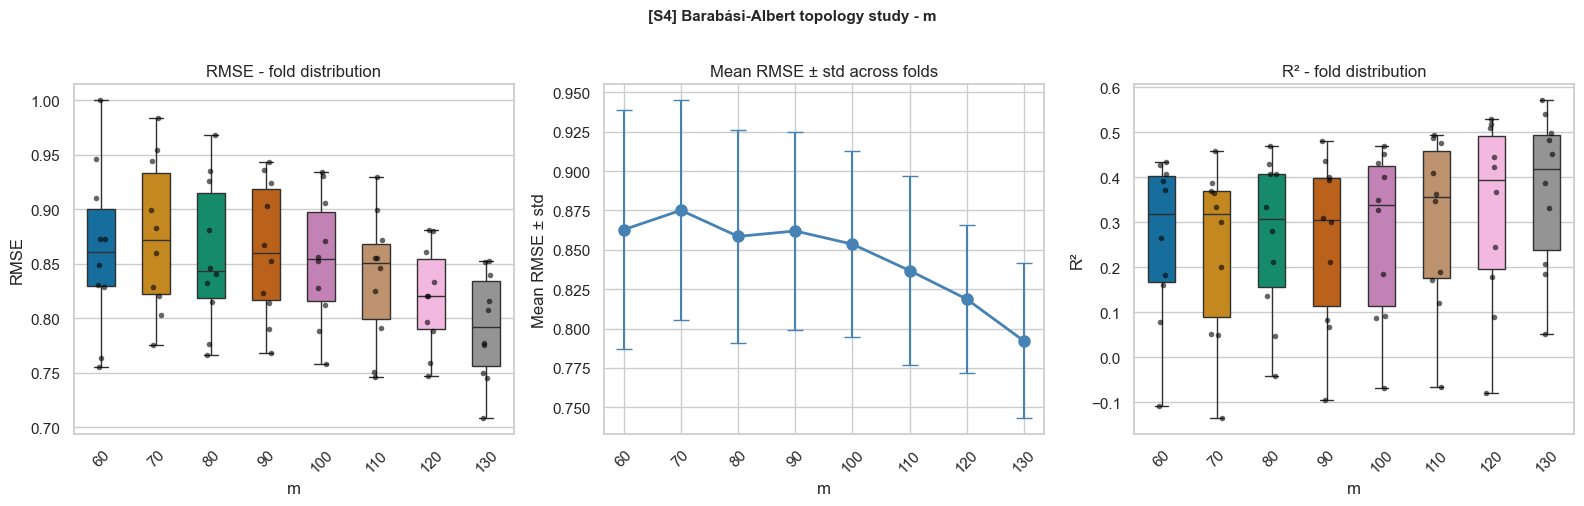

In [35]:
# ---------------------------------------------------------------------------
# 6.3 Barabási-Albert - sensitivity to m
# ---------------------------------------------------------------------------
ba_m_values = [60, 70, 80, 90, 100, 110, 120, 130]

df_shs_ba_m = run_topology_shs(
    X_anchor,
    y_anchor,
    topology="scale_free",
    param_name="m",
    param_values=ba_m_values,
    esn_params=PHASE_B_PARAMS,
    save_csv=OUTPUT_DIR / "topo_scale_free_m.csv",
)

plot_single_hp(
    df_shs_ba_m,
    "m",
    ba_m_values,
    label_map={v: str(v) for v in ba_m_values},
    title=f"[{ANALYSIS_SIGNAL}] Barabási-Albert topology study - m",
    save_path=OUTPUT_DIR / "shs_m.png",
)


#### 6.3. Barabási-Albert (Scale-free) - Sensitivity to `m`

The Barabási-Albert family is useful because it changes density while simultaneously
introducing **hub structure**.

If the best regime occurs at very small `m`, the benchmark prefers sparse almost-tree-like
reservoirs. If a second dense regime becomes competitive, the result may reflect a more
global random-matrix effect rather than any small-world or hub-specific advantage.


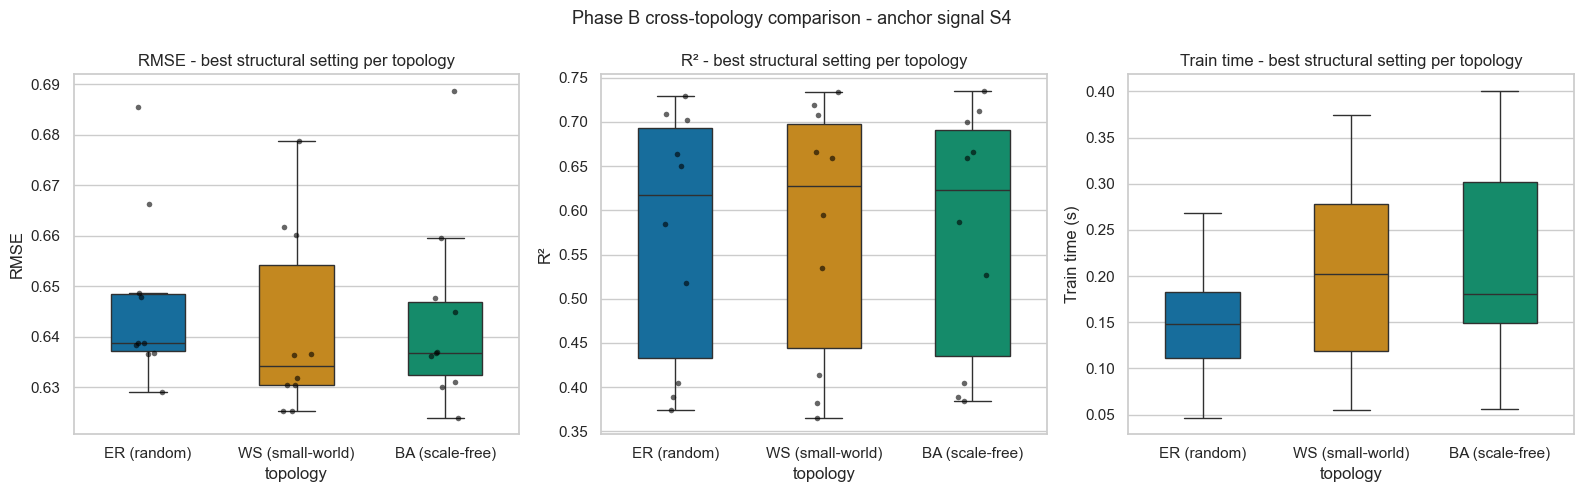

Best structural setting by topology

  ER : p = 0.0
  WS : {'k': 2, 'p_rewire': 0.3}
  BA : m = 1

Cross-topology summary

        topology  RMSE_mean  RMSE_std  R2_mean  R2_std  Time_mean  Time_std
     ER (random)    0.64666   0.01703  0.57240 0.14101    0.14774   0.06822
WS (small-world)    0.64163   0.01846  0.57770 0.14470    0.20271   0.10573
 BA (scale-free)    0.64353   0.01882  0.57634 0.14065    0.21052   0.11178


In [31]:
# ---------------------------------------------------------------------------
# 6.4 Cross-topology comparison - best structural setting per topology
# ---------------------------------------------------------------------------
def extract_best(df, param_name, best_val, label):
    out = df[df[param_name] == best_val][["fold", "rmse", "r2", "mae", "train_time_s"]].copy()
    out["topology"] = label
    return out


best_er_p = best_setting(df_shs_er_p, "p")
best_ws_k = best_setting(df_shs_ws_k, "k")
best_ws_prw_low = best_setting(df_shs_ws_prw_low, "p_rewire")
best_ws_prw_high = best_setting(df_shs_ws_prw_high, "p_rewire")
best_ba_m = best_setting(df_shs_ba_m, "m")

ws_candidates = [
    {
        "label": f"WS (small-world, k={best_ws_k}, p_rewire={FIXED_P_REWIRE})",
        "df": df_shs_ws_k,
        "param_name": "k",
        "best_val": best_ws_k,
        "topo_params": {"k": int(best_ws_k), "p_rewire": FIXED_P_REWIRE},
        "mean_rmse": df_shs_ws_k.groupby("k")["rmse"].mean().loc[best_ws_k],
    },
    {
        "label": f"WS (small-world, k={FIXED_K_LOW}, p_rewire={best_ws_prw_low})",
        "df": df_shs_ws_prw_low,
        "param_name": "p_rewire",
        "best_val": best_ws_prw_low,
        "topo_params": {"k": int(FIXED_K_LOW), "p_rewire": float(best_ws_prw_low)},
        "mean_rmse": df_shs_ws_prw_low.groupby("p_rewire")["rmse"].mean().loc[best_ws_prw_low],
    },
    {
        "label": f"WS (small-world, k={FIXED_K_HIGH}, p_rewire={best_ws_prw_high})",
        "df": df_shs_ws_prw_high,
        "param_name": "p_rewire",
        "best_val": best_ws_prw_high,
        "topo_params": {"k": int(FIXED_K_HIGH), "p_rewire": float(best_ws_prw_high)},
        "mean_rmse": df_shs_ws_prw_high.groupby("p_rewire")["rmse"].mean().loc[best_ws_prw_high],
    },
]
best_ws_candidate = min(ws_candidates, key=lambda d: d["mean_rmse"])

df_cross = pd.concat(
    [
        extract_best(df_shs_er_p, "p", best_er_p, "ER (random)"),
        extract_best(
            best_ws_candidate["df"],
            best_ws_candidate["param_name"],
            best_ws_candidate["best_val"],
            "WS (small-world)",
        ),
        extract_best(df_shs_ba_m, "m", best_ba_m, "BA (scale-free)"),
    ],
    ignore_index=True,
)

topo_order = ["ER (random)", "WS (small-world)", "BA (scale-free)"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df_cross, x="topology", y="rmse", order=topo_order, palette="colorblind", width=0.5, fliersize=0, ax=axes[0])
sns.stripplot(data=df_cross, x="topology", y="rmse", order=topo_order, color="black", size=4, alpha=0.6, jitter=True, ax=axes[0])
axes[0].set_title("RMSE - best structural setting per topology")
axes[0].set_ylabel("RMSE")

sns.boxplot(data=df_cross, x="topology", y="r2", order=topo_order, palette="colorblind", width=0.5, fliersize=0, ax=axes[1])
sns.stripplot(data=df_cross, x="topology", y="r2", order=topo_order, color="black", size=4, alpha=0.6, jitter=True, ax=axes[1])
axes[1].set_title("R² - best structural setting per topology")
axes[1].set_ylabel("R²")

sns.boxplot(data=df_cross, x="topology", y="train_time_s", order=topo_order, palette="colorblind", width=0.5, fliersize=0, ax=axes[2])
axes[2].set_title("Train time - best structural setting per topology")
axes[2].set_ylabel("Train time (s)")

plt.suptitle(f"Phase B cross-topology comparison - anchor signal {ANALYSIS_SIGNAL}", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase_b_cross_topology_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

phase_b_summary = (
    df_cross.groupby("topology")[["rmse", "r2", "train_time_s"]]
    .agg(["mean", "std"])
    .reindex(topo_order)
)
phase_b_summary.columns = [
    "RMSE_mean", "RMSE_std",
    "R2_mean", "R2_std",
    "Time_mean", "Time_std",
]
phase_b_summary = phase_b_summary.reset_index()
phase_b_summary.to_csv(OUTPUT_DIR / "phase_b_cross_topology_summary.csv", index=False)

best_topology_params = {
    "ER": {"topology": "random", "params": {"p": float(best_er_p)}},
    "WS": {"topology": "small_world", "params": best_ws_candidate["topo_params"]},
    "BA": {"topology": "scale_free", "params": {"m": int(best_ba_m)}},
}

print("Best structural setting by topology\n")
print(f"  ER : p = {best_er_p}")
print(f"  WS : {best_ws_candidate['topo_params']}")
print(f"  BA : m = {best_ba_m}")
print("\nCross-topology summary\n")
print(phase_b_summary.to_string(index=False, float_format=lambda x: f"{x:.5f}"))


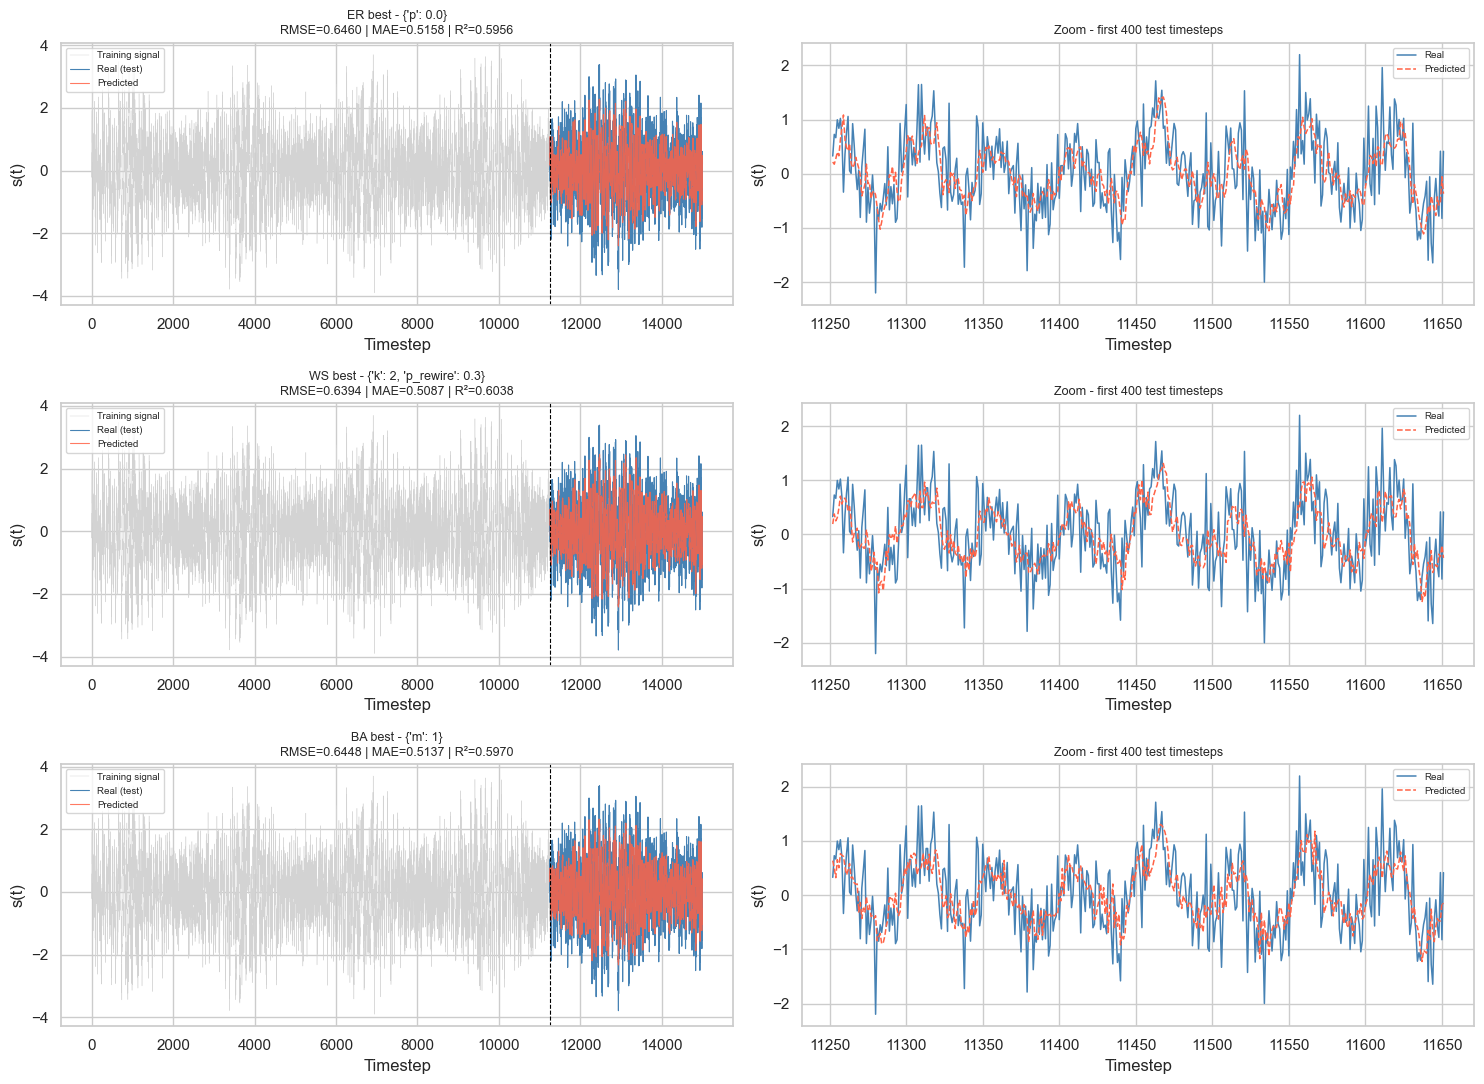

Figure saved → single_hp_outputs_4/phase_b_best_topology_prediction_grid.png


In [32]:
# ---------------------------------------------------------------------------
# Held-out prediction comparison with the best topology of each family
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(15, 11))

er_W, _ = make_reservoir_matrix(PHASE_B_PARAMS["N"], "random", best_topology_params["ER"]["params"])
ws_W, _ = make_reservoir_matrix(PHASE_B_PARAMS["N"], "small_world", best_topology_params["WS"]["params"])
ba_W, _ = make_reservoir_matrix(PHASE_B_PARAMS["N"], "scale_free", best_topology_params["BA"]["params"])

plot_signal_prediction(
    ANALYSIS_SIGNAL,
    anchor_cfg,
    PHASE_B_PARAMS,
    title=f"ER best - {best_topology_params['ER']['params']}",
    W_custom=er_W,
    ax_row=axes[0],
)
plot_signal_prediction(
    ANALYSIS_SIGNAL,
    anchor_cfg,
    PHASE_B_PARAMS,
    title=f"WS best - {best_topology_params['WS']['params']}",
    W_custom=ws_W,
    ax_row=axes[1],
)
plot_signal_prediction(
    ANALYSIS_SIGNAL,
    anchor_cfg,
    PHASE_B_PARAMS,
    title=f"BA best - {best_topology_params['BA']['params']}",
    W_custom=ba_W,
    ax_row=axes[2],
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase_b_best_topology_prediction_grid.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Figure saved → {OUTPUT_DIR / 'phase_b_best_topology_prediction_grid.png'}")


## 7. Conclusions

This notebook provides a **Notebook-2-style full ESN study** on the synthetic benchmark dataset:

1. **Benchmark-wide EDA** explains the difficulty progression before any model is fit.
2. **Phase A** combines a benchmark-core random search with a detailed anchor-signal OAT study.
3. **The refined search** narrows the hyperparameter space using the OAT evidence rather than an arbitrary second grid.
4. **Phase B** mirrors Notebook 2's reservoir study and tests whether performance is driven primarily by density, rewiring, or hub structure.

All artefacts needed to write the final thesis narrative are exported to:
- `single_hp_outputs_4/phase_a_*`
- `single_hp_outputs_4/shs_*`
- `single_hp_outputs_4/refined_grid_results.csv`
- `single_hp_outputs_4/topo_*`
- `single_hp_outputs_4/phase_b_*`

After execution, the three most important synthesis tables to carry into the written thesis are:
- the **best random-search configuration per core signal**,
- the **OAT sensitivity ranking on the anchor signal**,
- and the **cross-topology summary at each topology's best structural setting**.
